In [2]:
import pandas as pd
import numpy as np
from scipy.stats import kstest, shapiro, norm
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
import pingouin as pg
import itertools

import matplotlib
import matplotlib.pyplot as plt

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    "figure.figsize": [4.7747,3.5],
})

In [3]:
LINT_FEATURE = "lint_score"

In [4]:
# overview_df = pd.read_parquet("./output/overview.parquet")
overview_df = pd.read_parquet("./output/overview_extented.parquet")


In [5]:
overview_df

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, 0, 0, -1, -...","{'lint_level': [0, 0, -1, 0, -1, -1, 0, -1, -1...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."
roleplay,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 2, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, 0, -1, -1, -1, -1, 0, -1, ...","{'lint_level': [0, 0, 0, 0, -1, 0, 0, -1, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, -1, -1, -1, 0, -1,..."
meta,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 2, ...","{'lint_level': [2, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-1, 0, -1, 0, -1, -1, 0, -1, -...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-2, -1, -1, 0, -1, -2, 0, -1, ..."
cot,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 2, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 2, 2, 1, 2, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, 0, 0, -1, -1, 0, -1, -...","{'lint_level': [0, 0, 0, 0, -1, -1, 1, -1, 0, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."
meta_no_metric,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, -1, -1, -1, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -1, 0, -1,...","{'lint_level': [-2, -1, -1, -1, -1, -1, 0, -1,..."
meta_no_lint,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-2, -1, -1, 0, -1, -2, 0, -1, ..."


In [6]:
overview_df

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, 0, 0, -1, -...","{'lint_level': [0, 0, -1, 0, -1, -1, 0, -1, -1...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."
roleplay,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 2, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, 0, -1, -1, -1, -1, 0, -1, ...","{'lint_level': [0, 0, 0, 0, -1, 0, 0, -1, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, -1, -1, -1, 0, -1,..."
meta,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 2, ...","{'lint_level': [2, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-1, 0, -1, 0, -1, -1, 0, -1, -...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-2, -1, -1, 0, -1, -2, 0, -1, ..."
cot,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 2, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 2, 2, 1, 2, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, 0, 0, -1, -1, 0, -1, -...","{'lint_level': [0, 0, 0, 0, -1, -1, 1, -1, 0, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."
meta_no_metric,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, -1, -1, -1, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -1, 0, -1,...","{'lint_level': [-2, -1, -1, -1, -1, -1, 0, -1,..."
meta_no_lint,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-2, -1, -1, 0, -1, -2, 0, -1, ..."


In [7]:
zkb = pd.concat(
    {col: pd.json_normalize(overview_df[col]) for col in overview_df.columns},
    axis=1
)

zkb = zkb.apply(lambda x: x.map(np.array))
zkb

Org  \
                                                       lint_level   
standard        [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
roleplay        [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta            [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
cot             [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta_no_metric  [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta_no_lint    [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   

                                                                   \
                                                       lint_score   
standard        [51.787887017911295, 44.27195203809244, 42.014...   
roleplay        [51.787887017911295, 44.27195203809244, 42.014...   
meta            [51.787887017911295, 44.27195203809244, 42.014...   
cot             [51.787887017911295, 44.27195203809244, 42.014...   
meta_no_metric  [51.787887017911295, 44.27195203809244, 42.014...   
meta_no_lint    [51.787887017911295, 44.27195203809244, 42.014...   

                                                                   \
                                                   max_lint_score   
standard        [88.01970614660702, 80.87266839991977, 78.3902...   
roleplay        [88.01970614660702, 80.87266839991977, 78.3902...   
meta            [88.01970614660702, 80.87266839991977, 78.3902...   
cot             [88.01970614660702, 80.87266839991977, 78.3902...   
meta_no_metric  [88.01970614660702, 80.87266839991977, 78.3902...   
meta_no_lint    [88.01970614660702, 80.87266839991977, 78.3902...   

                                                                   \
                                    mean_content_words_per_clause   
standard        [5.150793650793651, 4.825757575757576, 4.27586...   
roleplay        [5.150793650793651, 4.825757575757576, 4.27586...   
meta            [5.150793650793651, 4.825757575757576, 4.27586...   
cot             [5.150793650793651, 4.825757575757576, 4.27586...   
meta_no_metric  [5.150793650793651, 4.825757575757576, 4.27586...   
meta_no_lint    [5.150793650793651, 4.825757575757576, 4.27586...   

                                                                   \
                                          mean_log_word_frequency   
standard        [4.2194244570113115, 4.487244917555749, 4.4093...   
roleplay        [4.2194244570113115, 4.487244917555749, 4.4093...   
meta            [4.2194244570113115, 4.487244917555749, 4.4093...   
cot             [4.2194244570113115, 4.487244917555749, 4.4093...   
meta_no_metric  [4.2194244570113115, 4.487244917555749, 4.4093...   
meta_no_lint    [4.2194244570113115, 4.487244917555749, 4.4093...   

                                                                   \
                                                     mean_max_sdl   
standard        [6.782608695652174, 7.090909090909091, 7.06666...   
roleplay        [6.782608695652174, 7.090909090909091, 7.06666...   
meta            [6.782608695652174, 7.090909090909091, 7.06666...   
cot             [6.782608695652174, 7.090909090909091, 7.06666...   
meta_no_metric  [6.782608695652174, 7.090909090909091, 7.06666...   
meta_no_lint    [6.782608695652174, 7.090909090909091, 7.06666...   

                                                                   \
                                                 mean_sent_length   
standard        [13.434782608695652, 15.272727272727273, 13.73...   
roleplay        [13.434782608695652, 15.272727272727273, 13.73...   
meta            [13.434782608695652, 15.272727272727273, 13.73...   
cot             [13.434782608695652, 15.272727272727273, 13.73...   
meta_no_metric  [13.434782608695652, 15.272727272727273, 13.73...   
meta_no_lint    [13.434782608695652, 15.272727272727273, 13.73...   

                                                                   \
                                                   min_lint_score   
standard        [25.91116226849178, 12.16223138953248

In [98]:
zkb.columns.levels

FrozenList([['Org', 'ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest', 'ChatGPT 4.1 mini/gpt-4.1-mini - diff', 'GPT 5.1 mini/gpt-5-mini - diff', 'Gemini/gemini-3-flash-preview - diff', 'Mistral/ministral-14b-latest - diff'], ['lint_level', 'lint_score', 'max_lint_score', 'mean_content_words_per_clause', 'mean_log_word_frequency', 'mean_max_sdl', 'mean_sent_length', 'min_lint_score', 'proportion_of_concrete_nouns', 'text_is_easy', 'text_length']])

In [101]:
zkb["Org"][["lint_level", "lint_score", 'mean_content_words_per_clause', 'mean_log_word_frequency', 'mean_max_sdl', 'proportion_of_concrete_nouns']].iloc[0]

lint_level                       [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...
lint_score                       [51.787887017911295, 44.27195203809244, 42.014...
mean_content_words_per_clause    [5.150793650793651, 4.825757575757576, 4.27586...
mean_log_word_frequency          [4.2194244570113115, 4.487244917555749, 4.4093...
mean_max_sdl                     [6.782608695652174, 7.090909090909091, 7.06666...
proportion_of_concrete_nouns     [0.2235294117647059, 0.38372093023255816, 0.51...
Name: standard, dtype: object

In [8]:
# Calculate max value for standard
lintlvl = zkb.xs(LINT_FEATURE, 1, 1)
lintlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103...","[-10.837340387071144, -11.717945105265855, -8....","[-4.517450223326719, -9.29620573354876, -9.869...","[-20.491910211027438, -21.09355145383897, -17....","[-12.452174166631742, -14.970689561995542, -9...."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783...","[-8.950911496217195, -7.341007145740463, -12.1...","[-4.310817698572123, -3.3619820267217833, -7.9...","[-20.552720624897667, -27.163550013634648, -17...","[-15.461479726164356, -13.430145443381463, -9...."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54...","[-9.361010019434168, -12.967162810460948, -14....","[-7.744431632020671, -9.624880481733356, -10.3...","[-27.63058386534123, -27.324002940022808, -19....","[-22.878532050109477, -20.110663394981103, -8...."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974...","[-7.8251378963908635, -10.737842415425604, -6....","[-4.364230884768382, -8.50374344426659, -5.052...","[-26.398741678209397, -21.575662419094044, -14...","[-11.8533067651124, -14.264377455172777, -13.0..."
meta_no_metric,"[51.787887017911295, 44.27195203809244, 42.014...","[42.28958633443007, 30.596528711552153, 31.171...","[41.7425487408478, 32.313725566640244, 32.3828...","[24.21361144906966, 15.451983306893368, 27.302...","[33.12911222903992, 24.939663988548645, 30.576...","[-9.498300683481226, -13.675423326540283, -10....","[-10.045338277063493, -11.958226471452193, -9....","[-27.574275568841635, -28.81996873119907, -14....","[-18.658774788871376, -19.33228804954379, -11...."
meta_no_lint,"[51.787887017911295, 44.27195203809244, 42.014...","[35.63656733739761, 29.216412158987538, 27.823...","[44.88418525326825, 27.939051535063115, 32.234...","[31.402888468691657, 18.163058828739622, 26.18...","[30.585526700917242, 21.062738000493937, 29.63...","[-16.151319680513687, -15.055539879104899, -14...","[-6.903701764643046, -16.33290050302932, -9.77...","[-20.384998549219638, -26.108893209352814, -15...","[-21.202360316994053, -23.2092140375985, -12.3..."


In [ ]:
# lintlvl = lintlvl.iloc[:4,0:5]

In [9]:
lintlvl = lintlvl.iloc[:4, 0:5]
lintlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103..."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783..."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54..."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974..."


In [10]:
lintlvl.iloc[:,0:5]

max_val = 0
for idx, row in lintlvl.iloc[:4,0:5].iterrows(): # Exclude meta_no_lint and meta_no_metric rows.
    vls = np.array([r for r in row.values]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    temp_max = np.max(vls)
    if temp_max > max_val:
        max_val = temp_max
print("MAX", max_val)

MAX 68.48813079213978


# Compare Prompts

In [11]:
dummy_models = []
all_gains = []
all_gains_v2 = []
postpre = []
for idx, row in lintlvl.iloc[:,0:5].iterrows():
    print("=====", idx)
    org_vls = row.values[0]
    vls = np.array([r for r in row.values[1:]]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    avg_model_score_per_text = np.mean(vls, axis = 0)
    post_min_pre = avg_model_score_per_text - org_vls
    max_min_pre = max_val - org_vls
    gain = post_min_pre / max_min_pre
    gain_v2 = post_min_pre / org_vls
    # NORMALIZED GAIN: https://www.physport.org/recommendations/Entry.cfm?ID=93334
    dummy_models.append(avg_model_score_per_text)
    all_gains.append(gain)
    all_gains_v2.append(gain_v2)
    postpre.append(post_min_pre)

===== standard
===== roleplay
===== meta
===== cot


In [12]:
lintlvl['dummy_model'] = dummy_models
lintlvl['post-min-pre'] = postpre
lintlvl['norm.gain'] = all_gains
lintlvl['norm.gain.v2'] = all_gains_v2

In [ ]:
lintlvl

In [ ]:
np.std(lintlvl.iloc[0, 12]), np.mean(lintlvl.iloc[0, -5])

In [ ]:
fig = sm.qqplot(lintlvl.iloc[0, -4], line='45')
plt.show()

In [ ]:
lintlvl.iloc[:4,:]

In [13]:
# Create for dummy model.

records = []

columns = list(lintlvl.columns.values)
print(columns)
for models in lintlvl.iloc[:4,:].itertuples():
    # print(prompt)
    print(len(models))
    print(models.Index)
    # print(models._2)
    # print(models)
    # print(models.column)
    # print(type(models), len(models))
    prompt_type = models.Index
    for index, lint_score in enumerate(models[1:]):
        # print(model)
        print("lengte", len(lint_score))
        print(index, lint_score)
        
        for text, ls in enumerate(lint_score):
            print("tekst", text, "lint score", ls)
            records.append(
                {
                    "tekst": text,
                    "prompt_type": prompt_type,
                    "model": columns[index],
                    "score": ls
                }
            )
    

['Org', 'ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest', 'dummy_model', 'post-min-pre', 'norm.gain', 'norm.gain.v2']
10
standard
lengte 40
0 [51.78788702 44.27195204 42.01484679 41.73047398 36.41633826 53.45974778
 33.7884481  34.29964099 35.63811598 35.942526   36.04815709 49.57545814
 53.04274792 53.68063737 43.20998372 30.74022212 53.16578509 64.48584901
 31.28092504 40.35790065 42.27971024 45.10012882 38.47826859 44.228571
 45.40480214 40.7485339  32.08573087 44.95534597 32.82549627 33.79125201
 56.32801162 58.84585487 45.96075655 63.74358302 39.10405441 46.74079593
 50.22265812 47.5599297  52.42048877 49.62476538]
tekst 0 lint score 51.787887017911295
tekst 1 lint score 44.27195203809244
tekst 2 lint score 42.01484679202095
tekst 3 lint score 41.73047397969161
tekst 4 lint score 36.416338260970214
tekst 5 lint score 53.45974778002985
tekst 6 lint score 33.788448096944194
tekst 7 lint score 34.2996409877365

In [ ]:
records

In [14]:
long_df = pd.DataFrame(records)
long_df

,tekst,prompt_type,model,score
0,0,standard,Org,51.787887
1,1,standard,Org,44.271952
2,2,standard,Org,42.014847
3,3,standard,Org,41.730474
4,4,standard,Org,36.416338
...,...,...,...,...
1435,35,cot,norm.gain.v2,-0.265620
1436,36,cot,norm.gain.v2,-0.252800
1437,37,cot,norm.gain.v2,-0.323173
1438,38,cot,norm.gain.v2,-0.306888


In [15]:
all_models_df = long_df[long_df.model.isin(['ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest'])] 
all_models_df

,tekst,prompt_type,model,score
40,0,standard,ChatGPT 4.1 mini/gpt-4.1-mini,40.950547
41,1,standard,ChatGPT 4.1 mini/gpt-4.1-mini,32.554007
42,2,standard,ChatGPT 4.1 mini/gpt-4.1-mini,33.782212
43,3,standard,ChatGPT 4.1 mini/gpt-4.1-mini,37.692759
44,4,standard,ChatGPT 4.1 mini/gpt-4.1-mini,29.102002
...,...,...,...,...
1275,35,cot,Mistral/ministral-14b-latest,32.143897
1276,36,cot,Mistral/ministral-14b-latest,38.214901
1277,37,cot,Mistral/ministral-14b-latest,29.917135
1278,38,cot,Mistral/ministral-14b-latest,33.587112


In [16]:
long_df.loc[(long_df.prompt_type == 'standard') & (long_df.model == 'Org'), 'prompt_type'] = 'Original'
long_df

,tekst,prompt_type,model,score
0,0,Original,Org,51.787887
1,1,Original,Org,44.271952
2,2,Original,Org,42.014847
3,3,Original,Org,41.730474
4,4,Original,Org,36.416338
...,...,...,...,...
1435,35,cot,norm.gain.v2,-0.265620
1436,36,cot,norm.gain.v2,-0.252800
1437,37,cot,norm.gain.v2,-0.323173
1438,38,cot,norm.gain.v2,-0.306888


In [17]:
long_df

,tekst,prompt_type,model,score
0,0,Original,Org,51.787887
1,1,Original,Org,44.271952
2,2,Original,Org,42.014847
3,3,Original,Org,41.730474
4,4,Original,Org,36.416338
...,...,...,...,...
1435,35,cot,norm.gain.v2,-0.265620
1436,36,cot,norm.gain.v2,-0.252800
1437,37,cot,norm.gain.v2,-0.323173
1438,38,cot,norm.gain.v2,-0.306888


In [18]:
# This has the orignal lint scores for tekst without prompt (baseline) and contains 4 prompts * 40 dummy (mean) values.
anova_check_df = long_df[(long_df.model.isin(['dummy_model'])) | ((long_df.prompt_type == 'Original') & (long_df.model == 'Org'))]
anova_check_df

,tekst,prompt_type,model,score
0,0,Original,Org,51.787887
1,1,Original,Org,44.271952
2,2,Original,Org,42.014847
3,3,Original,Org,41.730474
4,4,Original,Org,36.416338
...,...,...,...,...
1315,35,cot,dummy_model,34.325487
1316,36,cot,dummy_model,37.526374
1317,37,cot,dummy_model,32.189839
1318,38,cot,dummy_model,36.333284


In [153]:
anova_check_df.where(anova_check_df.tekst.isin([18, 28])).values

array([[nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [18.0, 'Original', 'Org', 31.280925040846626],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [28.0, 'Original', 'Org', 32.82549626823115],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, 

In [19]:
prompts = list(anova_check_df.prompt_type.unique())
prompt_combinations = list(itertools.combinations(prompts, r = 2))

In [20]:
anova_check_df[anova_check_df.prompt_type == 'Original'].score.values - anova_check_df[anova_check_df.prompt_type == 'standard'].score.values

array([12.07471875, 14.26959796, 11.28389659,  8.19883192, 11.33879681,
       14.19739038,  3.48390824,  5.70616922,  8.79450784,  6.90862435,
        6.94053476, 11.15188474, 12.34309465, 15.00041079, 17.73872852,
        7.07482047, 26.08870529, 27.71015013,  4.34417746, 10.79189356,
       10.55632385, 12.5004616 , 10.14283809,  8.75909018, 14.25314794,
        7.69812909,  5.67561413, 11.63096119,  3.46599304,  4.12868818,
       17.67327467, 17.59242513, 11.35357049, 19.63120717,  4.75248782,
       10.27651322, 11.55606214, 15.38525525, 19.73671569, 14.58800121])

In [21]:
for prp in list(anova_check_df.prompt_type.unique())[1:]:
    print(prp)
    res = anova_check_df[anova_check_df.prompt_type == 'Original'].score.values - anova_check_df[anova_check_df.prompt_type == prp].score.values
    if np.min(res) > 0:
        print("good vibes only", np.min(res))
    else:
        print("fck", np.min(res), np.where(res < 0.0))
        print(res)

standard
good vibes only 3.465993044729615
roleplay
good vibes only 2.8620520270352046
meta
fck -5.407953257958724 (array([18, 28]),)
[16.90363939 17.50667741 13.21442829  9.84438262  9.87093643 17.99805089
  6.72462411  5.06559849  6.59039397  4.26693053  7.40232338 16.95418961
 18.26136945 18.55040367 18.5740706   7.12634334 26.70219564 33.4306977
 -0.26306922  9.95923178 10.28458149 11.29499302  6.32691732  9.93443569
 14.93698655 10.71842481  6.47037485 13.8727664  -5.40795326  4.2070457
 20.53649684 23.3849712  11.41187108 30.48199414  9.13335002 14.77401671
 16.25715942 20.56038594 20.43840346 15.18460142]
cot
good vibes only 2.261803699119149


## Table for paper

In [181]:
agg_table = anova_check_df.groupby('prompt_type')['score'].aggregate([np.min, np.median, np.max, np.mean, np.std])
print(agg_table.to_latex(escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & min & median & max & mean & std \\
prompt\_type &  &  &  &  &  \\
\midrule
Original & 30.74 & 44.25 & 64.49 & 44.38 & 8.72 \\
cot & 25.85 & 32.87 & 42.66 & 33.36 & 4.21 \\
meta & 23.61 & 31.61 & 38.23 & 31.15 & 3.40 \\
roleplay & 24.09 & 32.24 & 43.50 & 33.18 & 5.27 \\
standard & 23.67 & 32.39 & 44.11 & 32.71 & 4.99 \\
\bottomrule
\end{tabular}



## Is normality assumption met?

In [133]:
pg.normality(data=anova_check_df, dv='score', group='prompt_type')

,W,pval,normal
prompt_type,,,
Original,0.965463,0.256209,True
standard,0.973994,0.476850,True
roleplay,0.950367,0.078071,True
meta,0.977048,0.581151,True
cot,0.975702,0.533840,True


In [134]:
pg.sphericity(data=anova_check_df, dv='score', subject='tekst', within='prompt_type')

SpherResults(spher=False, W=0.025925737732245865, chi2=136.66508849349623, dof=9, pval=6.339681686692108e-25)

In [135]:
# if sphericity = False, report the p_GG_corr p value (Greenhouse Geisser)
print(pg.rm_anova(data=anova_check_df, dv='score', subject='tekst', within='prompt_type', detailed=True, correction=True, effsize='n2'))

        Source           SS   DF           MS           F         p_unc  \
0  prompt_type  4564.740963    4  1141.185241  113.017496  4.854143e-45   
1        Error  1575.197677  156    10.097421         NaN           NaN   

      p_GG_corr        n2       eps sphericity   W_spher       p_spher  
0  2.877428e-18  0.419561  0.371116      False  0.025926  6.339682e-25  
1           NaN       NaN       NaN        NaN       NaN           NaN  


In [136]:
# If p corrected value <0.05, then you can assume it is statistically significant. 

posthocs = pg.pairwise_tests(
    data=anova_check_df, dv='score', subject='tekst', within='prompt_type', padjust="bonf", effsize='eta_square'
)
posthocs

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,eta_square
0,prompt_type,Original,cot,True,True,12.256503,39.0,two-sided,5.968329e-15,5.968329e-14,bonf,1.132e+12,0.387410
1,prompt_type,Original,meta,True,True,10.648633,39.0,two-sided,4.189478e-13,4.189478e-12,bonf,1.905e+10,0.493865
2,prompt_type,Original,roleplay,True,True,14.207627,39.0,two-sided,5.265307e-17,5.265307e-16,bonf,1.081e+14,0.370869
3,prompt_type,Original,standard,True,True,13.100121,39.0,two-sided,7.303104e-16,7.303104e-15,bonf,8.559e+12,0.396973
4,prompt_type,cot,meta,True,True,4.105769,39.0,two-sided,1.993453e-04,1.993453e-03,bonf,129.988,0.075488
5,prompt_type,cot,roleplay,True,True,0.522078,39.0,two-sided,6.045688e-01,1.000000e+00,bonf,0.194,0.000340
6,prompt_type,cot,standard,True,True,1.908248,39.0,two-sided,6.374004e-02,6.374004e-01,bonf,0.881,0.004756
7,prompt_type,meta,roleplay,True,True,-3.212943,39.0,two-sided,2.635623e-03,2.635623e-02,bonf,12.957,0.048816
8,prompt_type,meta,standard,True,True,-2.829181,39.0,two-sided,7.334737e-03,7.334737e-02,bonf,5.319,0.031839
9,prompt_type,roleplay,standard,True,True,2.095658,39.0,two-sided,4.265321e-02,4.265321e-01,bonf,1.216,0.002022


In [ ]:
zh = anova_check_df.groupby('prompt_type')
zh.groups.items()

In [ ]:
valk_prompts = dict(
    {
        'Original': dict(tuple(zh))['Original']['score'].values,
        'Standard': dict(tuple(zh))['standard']['score'].values,
        'Roleplay': dict(tuple(zh))['roleplay']['score'].values,
        'CoT': dict(tuple(zh))['cot']['score'].values,
        'Meta': dict(tuple(zh))['meta']['score'].values,
    }

)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(valk_prompts.values())
ax.set_xticklabels(list(valk_prompts.keys()))
ax.set_title("LiNT score per prompt type")
ax.set_ylabel("LiNT score")
ax.set_xlabel("Prompt type")
ax.axhline(y=34, color='r', linestyle='-', label="LiNT = 34 (goal)")# ax.
ax.grid(axis='y')
ax.legend()
plt.show()

## Model * Prompt interaction tryout

In [22]:
all_models_df

,tekst,prompt_type,model,score
40,0,standard,ChatGPT 4.1 mini/gpt-4.1-mini,40.950547
41,1,standard,ChatGPT 4.1 mini/gpt-4.1-mini,32.554007
42,2,standard,ChatGPT 4.1 mini/gpt-4.1-mini,33.782212
43,3,standard,ChatGPT 4.1 mini/gpt-4.1-mini,37.692759
44,4,standard,ChatGPT 4.1 mini/gpt-4.1-mini,29.102002
...,...,...,...,...
1275,35,cot,Mistral/ministral-14b-latest,32.143897
1276,36,cot,Mistral/ministral-14b-latest,38.214901
1277,37,cot,Mistral/ministral-14b-latest,29.917135
1278,38,cot,Mistral/ministral-14b-latest,33.587112


In [37]:
pg.normality(data=all_models_df, dv='score', group='prompt_type')

,W,pval,normal
prompt_type,,,
standard,0.992146,0.531405,True
roleplay,0.985607,0.096966,True
meta,0.959709,0.000136,False
cot,0.965249,0.000477,False


In [39]:
pg.sphericity(data=all_models_df, dv='score', subject='tekst', within=['prompt_type', 'model'])

ValueError: If using two-way repeated measures design, at least one factor must have exactly two levels. More complex designs are not yet supported.

In [ ]:
stats.sphe

In [40]:
print(pg.rm_anova(data=all_models_df, dv='score', subject='tekst', within=['prompt_type', 'model'], detailed=True, correction=True))

                Source            SS  ddof1  ddof2           MS           F  \
0          prompt_type    486.469433      3    117   162.156478    9.507374   
1                model  14853.452046      3    117  4951.150682  179.659034   
2  prompt_type * model    461.637228      9    351    51.293025    4.184813   

          p_unc     p_GG_corr       ng2       eps  
0  1.139522e-05  4.751642e-04  0.023040  0.568344  
1  1.252614e-43  6.336228e-28  0.418628  0.618047  
2  3.760642e-05  7.672564e-03  0.021890  0.330022  


/opt/homebrew/Caskroom/miniforge/base/envs/lint2test/lib/python3.11/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [41]:
posthocs = pg.pairwise_tests(
    data=all_models_df, dv='score', subject='tekst', within=['prompt_type', 'model'], padjust="bonf", effsize='eta_square'
)
posthocs

,Contrast,prompt_type,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,eta_square
0,prompt_type,-,cot,meta,True,True,4.105769,39.0,two-sided,1.993453e-04,1.196072e-03,bonf,129.988,0.075488
1,prompt_type,-,cot,roleplay,True,True,0.522078,39.0,two-sided,6.045688e-01,1.000000e+00,bonf,0.194,0.000340
2,prompt_type,-,cot,standard,True,True,1.908248,39.0,two-sided,6.374004e-02,3.824402e-01,bonf,0.881,0.004756
3,prompt_type,-,meta,roleplay,True,True,-3.212943,39.0,two-sided,2.635623e-03,1.581374e-02,bonf,12.957,0.048816
4,prompt_type,-,meta,standard,True,True,-2.829181,39.0,two-sided,7.334737e-03,4.400842e-02,bonf,5.319,0.031839
5,prompt_type,-,roleplay,standard,True,True,2.095658,39.0,two-sided,4.265321e-02,2.559192e-01,bonf,1.216,0.002022
6,model,-,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,True,True,-6.430140,39.0,two-sided,1.310005e-07,7.860031e-07,bonf,1.14e+05,0.059911
7,model,-,ChatGPT 4.1 mini/gpt-4.1-mini,Gemini/gemini-3-flash-preview,True,True,15.880469,39.0,two-sided,1.281044e-18,7.686266e-18,bonf,3.919e+15,0.594388
8,model,-,ChatGPT 4.1 mini/gpt-4.1-mini,Mistral/ministral-14b-latest,True,True,6.377071,39.0,two-sided,1.551743e-07,9.310461e-07,bonf,9.724e+04,0.061132
9,model,-,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,True,True,15.658124,39.0,two-sided,2.064380e-18,1.238628e-17,bonf,2.47e+15,0.651167


In [81]:
print(posthocs[posthocs.Contrast == "prompt_type * model"][["prompt_type", "A", "B", "T", "p_corr", "eta_square"]].to_latex(escape=True, float_format="%.2f", index=False))

\begin{tabular}{lllrrr}
\toprule
prompt\_type & A & B & T & p\_corr & eta\_square \\
\midrule
cot & ChatGPT 4.1 mini/gpt-4.1-mini & GPT 5.1 mini/gpt-5-mini & -4.38 & 0.00 & 0.05 \\
cot & ChatGPT 4.1 mini/gpt-4.1-mini & Gemini/gemini-3-flash-preview & 9.24 & 0.00 & 0.49 \\
cot & ChatGPT 4.1 mini/gpt-4.1-mini & Mistral/ministral-14b-latest & 7.71 & 0.00 & 0.11 \\
cot & GPT 5.1 mini/gpt-5-mini & Gemini/gemini-3-flash-preview & 10.60 & 0.00 & 0.57 \\
cot & GPT 5.1 mini/gpt-5-mini & Mistral/ministral-14b-latest & 8.56 & 0.00 & 0.25 \\
cot & Gemini/gemini-3-flash-preview & Mistral/ministral-14b-latest & -6.18 & 0.00 & 0.26 \\
meta & ChatGPT 4.1 mini/gpt-4.1-mini & GPT 5.1 mini/gpt-5-mini & -1.01 & 1.00 & 0.01 \\
meta & ChatGPT 4.1 mini/gpt-4.1-mini & Gemini/gemini-3-flash-preview & 13.39 & 0.00 & 0.67 \\
meta & ChatGPT 4.1 mini/gpt-4.1-mini & Mistral/ministral-14b-latest & 4.04 & 0.01 & 0.12 \\
meta & GPT 5.1 mini/gpt-5-mini & Gemini/gemini-3-flash-preview & 9.49 & 0.00 & 0.55 \\
meta & GPT 

In [23]:
interact = list(itertools.product(list(all_models_df.model.unique()), list(all_models_df.prompt_type.unique())))

In [24]:
interaction_dict = dict()
for inter1, inter2 in interact:
    interaction_dict[f"{inter1} * {inter2}"] = []

In [25]:
interaction_dict

{'ChatGPT 4.1 mini/gpt-4.1-mini * standard': [],
 'ChatGPT 4.1 mini/gpt-4.1-mini * roleplay': [],
 'ChatGPT 4.1 mini/gpt-4.1-mini * meta': [],
 'ChatGPT 4.1 mini/gpt-4.1-mini * cot': [],
 'GPT 5.1 mini/gpt-5-mini * standard': [],
 'GPT 5.1 mini/gpt-5-mini * roleplay': [],
 'GPT 5.1 mini/gpt-5-mini * meta': [],
 'GPT 5.1 mini/gpt-5-mini * cot': [],
 'Gemini/gemini-3-flash-preview * standard': [],
 'Gemini/gemini-3-flash-preview * roleplay': [],
 'Gemini/gemini-3-flash-preview * meta': [],
 'Gemini/gemini-3-flash-preview * cot': [],
 'Mistral/ministral-14b-latest * standard': [],
 'Mistral/ministral-14b-latest * roleplay': [],
 'Mistral/ministral-14b-latest * meta': [],
 'Mistral/ministral-14b-latest * cot': []}

In [26]:
for idx, rw in all_models_df.iterrows():
    print(rw.model, rw.prompt_type)
    interaction_dict[f"{rw.model} * {rw.prompt_type}"].append(rw.score)

ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-mini standard
ChatGPT 4.1 mini/gpt-4.1-

In [27]:
mean_p_inter = pd.DataFrame(interaction_dict)
mean_p_inter

,ChatGPT 4.1 mini/gpt-4.1-mini * standard,ChatGPT 4.1 mini/gpt-4.1-mini * roleplay,ChatGPT 4.1 mini/gpt-4.1-mini * meta,ChatGPT 4.1 mini/gpt-4.1-mini * cot,GPT 5.1 mini/gpt-5-mini * standard,GPT 5.1 mini/gpt-5-mini * roleplay,GPT 5.1 mini/gpt-5-mini * meta,GPT 5.1 mini/gpt-5-mini * cot,Gemini/gemini-3-flash-preview * standard,Gemini/gemini-3-flash-preview * roleplay,Gemini/gemini-3-flash-preview * meta,Gemini/gemini-3-flash-preview * cot,Mistral/ministral-14b-latest * standard,Mistral/ministral-14b-latest * roleplay,Mistral/ministral-14b-latest * meta,Mistral/ministral-14b-latest * cot
0,40.950547,42.836976,42.426877,43.962749,47.270437,47.477069,44.043455,47.423656,31.295977,31.235166,24.157303,25.389145,39.335713,36.326407,28.909355,39.934580
1,32.554007,36.930945,31.304789,33.534110,34.975746,40.909970,34.647072,35.768209,23.178401,17.108402,16.947949,22.696290,29.301262,30.841807,24.161289,30.007575
2,33.782212,29.903615,27.986886,35.795626,32.145224,34.083483,31.642991,36.962280,24.892855,24.579738,22.026977,27.963415,32.103509,32.783708,33.544820,28.974059
3,37.692759,29.340862,36.480907,37.132238,37.450041,36.711792,34.201725,34.664073,23.543418,26.551039,20.998072,28.423656,35.440351,33.652241,35.863662,35.591209
4,29.102002,29.891098,33.084710,29.498146,28.128813,33.648251,31.340135,31.643294,16.278454,17.759418,18.233698,19.684382,26.800897,25.209368,23.523064,22.572311
5,46.329740,39.668403,41.858846,39.559302,38.055754,48.704364,38.949371,44.259695,30.910363,30.772644,29.471336,25.307930,41.753572,40.948174,31.567234,34.050240
6,31.566487,31.667005,32.552209,31.533973,31.323645,33.087708,28.493426,37.588624,27.858514,26.051641,21.266204,28.942399,30.469514,32.899229,25.943457,28.041581
7,30.601478,20.206393,31.966233,30.899426,31.969806,32.203811,29.413589,32.866647,23.608450,23.537172,22.913713,28.622999,28.194153,29.900911,32.642635,30.811628
8,27.965291,31.101280,31.812236,30.324473,32.445566,33.266141,29.571385,34.387759,16.956429,23.338172,27.552918,30.878529,30.007146,28.858061,27.254348,30.275125
9,31.977631,28.952250,34.432839,31.739161,30.890589,32.017479,32.713711,30.868285,23.449311,26.170869,29.624400,28.558308,29.818076,29.203993,29.931431,29.627788


In [32]:
mean_p_inter.to_excel("./output/modelXprompts.xlsx")

### Actual plot

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

# matplotlib.use("pgf")
# # matplotlib.rcParams.update({})
# matplotlib.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     'font.family': 'serif',
#     'text.usetex': True,
#     'pgf.rcfonts': False,
#     "figure.figsize": [4.7747,3.5],
# })

In [34]:
replacements = {
    "ChatGPT 4.1 mini/gpt-4.1-mini": "GPT-4.1 mini",
    "GPT 5.1 mini/gpt-5-mini": "GPT-5 mini",
    "Gemini/gemini-3-flash-preview": "Gemini 3 Flash Preview",
    "Mistral/ministral-14b-latest": "Ministral 14B",
}

new_cols = []

for col in mean_p_inter.columns:
    model, prompt = col.split(' * ')
    model2 = replacements[model]
    prompt2 = prompt.capitalize()
    print(model2, prompt2)
    new_cols.append(f"{model2} * {prompt2}")

GPT-4.1 mini Standard
GPT-4.1 mini Roleplay
GPT-4.1 mini Meta
GPT-4.1 mini Cot
GPT-5 mini Standard
GPT-5 mini Roleplay
GPT-5 mini Meta
GPT-5 mini Cot
Gemini 3 Flash Preview Standard
Gemini 3 Flash Preview Roleplay
Gemini 3 Flash Preview Meta
Gemini 3 Flash Preview Cot
Ministral 14B Standard
Ministral 14B Roleplay
Ministral 14B Meta
Ministral 14B Cot


In [143]:
new_cols

['GPT-4.1 mini * Standard',
 'GPT-4.1 mini * Roleplay',
 'GPT-4.1 mini * Meta',
 'GPT-4.1 mini * Cot',
 'GPT-5 mini * Standard',
 'GPT-5 mini * Roleplay',
 'GPT-5 mini * Meta',
 'GPT-5 mini * Cot',
 'Gemini 3 Flash Preview * Standard',
 'Gemini 3 Flash Preview * Roleplay',
 'Gemini 3 Flash Preview * Meta',
 'Gemini 3 Flash Preview * Cot',
 'Ministral 14B * Standard',
 'Ministral 14B * Roleplay',
 'Ministral 14B * Meta',
 'Ministral 14B * Cot']

In [35]:
mean_p_inter.columns = new_cols

In [36]:
mean_p_inter

,GPT-4.1 mini * Standard,GPT-4.1 mini * Roleplay,GPT-4.1 mini * Meta,GPT-4.1 mini * Cot,GPT-5 mini * Standard,GPT-5 mini * Roleplay,GPT-5 mini * Meta,GPT-5 mini * Cot,Gemini 3 Flash Preview * Standard,Gemini 3 Flash Preview * Roleplay,Gemini 3 Flash Preview * Meta,Gemini 3 Flash Preview * Cot,Ministral 14B * Standard,Ministral 14B * Roleplay,Ministral 14B * Meta,Ministral 14B * Cot
0,40.950547,42.836976,42.426877,43.962749,47.270437,47.477069,44.043455,47.423656,31.295977,31.235166,24.157303,25.389145,39.335713,36.326407,28.909355,39.934580
1,32.554007,36.930945,31.304789,33.534110,34.975746,40.909970,34.647072,35.768209,23.178401,17.108402,16.947949,22.696290,29.301262,30.841807,24.161289,30.007575
2,33.782212,29.903615,27.986886,35.795626,32.145224,34.083483,31.642991,36.962280,24.892855,24.579738,22.026977,27.963415,32.103509,32.783708,33.544820,28.974059
3,37.692759,29.340862,36.480907,37.132238,37.450041,36.711792,34.201725,34.664073,23.543418,26.551039,20.998072,28.423656,35.440351,33.652241,35.863662,35.591209
4,29.102002,29.891098,33.084710,29.498146,28.128813,33.648251,31.340135,31.643294,16.278454,17.759418,18.233698,19.684382,26.800897,25.209368,23.523064,22.572311
5,46.329740,39.668403,41.858846,39.559302,38.055754,48.704364,38.949371,44.259695,30.910363,30.772644,29.471336,25.307930,41.753572,40.948174,31.567234,34.050240
6,31.566487,31.667005,32.552209,31.533973,31.323645,33.087708,28.493426,37.588624,27.858514,26.051641,21.266204,28.942399,30.469514,32.899229,25.943457,28.041581
7,30.601478,20.206393,31.966233,30.899426,31.969806,32.203811,29.413589,32.866647,23.608450,23.537172,22.913713,28.622999,28.194153,29.900911,32.642635,30.811628
8,27.965291,31.101280,31.812236,30.324473,32.445566,33.266141,29.571385,34.387759,16.956429,23.338172,27.552918,30.878529,30.007146,28.858061,27.254348,30.275125
9,31.977631,28.952250,34.432839,31.739161,30.890589,32.017479,32.713711,30.868285,23.449311,26.170869,29.624400,28.558308,29.818076,29.203993,29.931431,29.627788


In [209]:
plt.close()

In [37]:
dlt = mean_p_inter.boxplot(rot=90, figsize=(10, 12), return_type="dict")

In [42]:
dlt['whiskers'].values

AttributeError: 'list' object has no attribute 'values'

In [44]:
boxp = mean_p_inter.boxplot(rot=90, figsize=(10, 12))
# plt.show()
boxp.set_title("Lint score per interaction model*prompt")
boxp.set_ylabel("LiNT-score (lower is better)")
boxp.set_xlabel("Model * Prompt type")
boxp.axhline(y=34, color='r', linestyle='-', label="LiNT = 34 (goal)")# ax.
# boxp.tight_layout()
boxp.grid(axis='x')
boxp.legend()

fig = plt.gcf()
fig.tight_layout()

In [45]:
boxp.axes

<Axes: title={'center': 'Lint score per interaction model*prompt'}, xlabel='Model * Prompt type', ylabel='LiNT-score (lower is better)'>

In [46]:
fig.show()

/var/folders/8y/ltkqq_vs4wj1g46bz6tb7xb80000gp/T/ipykernel_1631/89474557.py:1: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  fig.show()


In [206]:
fig.savefig('huts2.png')

In [211]:
fig.savefig("thingy.pgf")

In [ ]:
plt.savefig('model_prompt_interactions4.pgf')

: 

In [1]:
mean_p_inter.to_excel("output.xslx")

NameError: name 'mean_p_inter' is not defined

In [89]:
print(mean_p_inter.aggregate([np.min, np.median, np.max, np.mean, np.std]).transpose().to_latex(escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & min & median & max & mean & std \\
\midrule
ChatGPT 4.1 mini/gpt-4.1-mini * standard & 25.67 & 33.92 & 46.33 & 34.86 & 5.16 \\
ChatGPT 4.1 mini/gpt-4.1-mini * roleplay & 20.21 & 34.20 & 44.97 & 34.59 & 5.83 \\
ChatGPT 4.1 mini/gpt-4.1-mini * meta & 24.35 & 34.05 & 43.52 & 35.03 & 4.89 \\
ChatGPT 4.1 mini/gpt-4.1-mini * cot & 26.19 & 35.47 & 50.71 & 35.86 & 5.68 \\
GPT 5.1 mini/gpt-5-mini * standard & 25.96 & 37.61 & 52.71 & 37.11 & 6.42 \\
GPT 5.1 mini/gpt-5-mini * roleplay & 27.50 & 38.93 & 54.24 & 39.06 & 7.47 \\
GPT 5.1 mini/gpt-5-mini * meta & 24.37 & 35.34 & 68.49 & 36.30 & 8.10 \\
GPT 5.1 mini/gpt-5-mini * cot & 26.79 & 38.30 & 53.45 & 38.81 & 6.65 \\
Gemini/gemini-3-flash-preview * standard & 16.14 & 24.65 & 37.69 & 24.97 & 4.86 \\
Gemini/gemini-3-flash-preview * roleplay & 15.74 & 26.00 & 34.42 & 25.68 & 4.97 \\
Gemini/gemini-3-flash-preview * meta & 14.99 & 21.95 & 31.99 & 22.05 & 4.07 \\
Gemini/gemini-3-flash-preview * cot & 19.68 & 26.93 &

In [84]:
print(mean_p_inter.to_latex(escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrrrrrrrrrrrrr}
\toprule
 & ChatGPT 4.1 mini/gpt-4.1-mini * standard & ChatGPT 4.1 mini/gpt-4.1-mini * roleplay & ChatGPT 4.1 mini/gpt-4.1-mini * meta & ChatGPT 4.1 mini/gpt-4.1-mini * cot & GPT 5.1 mini/gpt-5-mini * standard & GPT 5.1 mini/gpt-5-mini * roleplay & GPT 5.1 mini/gpt-5-mini * meta & GPT 5.1 mini/gpt-5-mini * cot & Gemini/gemini-3-flash-preview * standard & Gemini/gemini-3-flash-preview * roleplay & Gemini/gemini-3-flash-preview * meta & Gemini/gemini-3-flash-preview * cot & Mistral/ministral-14b-latest * standard & Mistral/ministral-14b-latest * roleplay & Mistral/ministral-14b-latest * meta & Mistral/ministral-14b-latest * cot \\
\midrule
0 & 40.95 & 42.84 & 42.43 & 43.96 & 47.27 & 47.48 & 44.04 & 47.42 & 31.30 & 31.24 & 24.16 & 25.39 & 39.34 & 36.33 & 28.91 & 39.93 \\
1 & 32.55 & 36.93 & 31.30 & 33.53 & 34.98 & 40.91 & 34.65 & 35.77 & 23.18 & 17.11 & 16.95 & 22.70 & 29.30 & 30.84 & 24.16 & 30.01 \\
2 & 33.78 & 29.90 & 27.99 & 35.80 & 32.15 & 34.08 & 3

# Model comparrison

In [7]:
lintlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103...","[-10.837340387071144, -11.717945105265855, -8....","[-4.517450223326719, -9.29620573354876, -9.869...","[-20.491910211027438, -21.09355145383897, -17....","[-12.452174166631742, -14.970689561995542, -9...."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783...","[-8.950911496217195, -7.341007145740463, -12.1...","[-4.310817698572123, -3.3619820267217833, -7.9...","[-20.552720624897667, -27.163550013634648, -17...","[-15.461479726164356, -13.430145443381463, -9...."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54...","[-9.361010019434168, -12.967162810460948, -14....","[-7.744431632020671, -9.624880481733356, -10.3...","[-27.63058386534123, -27.324002940022808, -19....","[-22.878532050109477, -20.110663394981103, -8...."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974...","[-7.8251378963908635, -10.737842415425604, -6....","[-4.364230884768382, -8.50374344426659, -5.052...","[-26.398741678209397, -21.575662419094044, -14...","[-11.8533067651124, -14.264377455172777, -13.0..."
meta_no_metric,"[51.787887017911295, 44.27195203809244, 42.014...","[42.28958633443007, 30.596528711552153, 31.171...","[41.7425487408478, 32.313725566640244, 32.3828...","[24.21361144906966, 15.451983306893368, 27.302...","[33.12911222903992, 24.939663988548645, 30.576...","[-9.498300683481226, -13.675423326540283, -10....","[-10.045338277063493, -11.958226471452193, -9....","[-27.574275568841635, -28.81996873119907, -14....","[-18.658774788871376, -19.33228804954379, -11...."
meta_no_lint,"[51.787887017911295, 44.27195203809244, 42.014...","[35.63656733739761, 29.216412158987538, 27.823...","[44.88418525326825, 27.939051535063115, 32.234...","[31.402888468691657, 18.163058828739622, 26.18...","[30.585526700917242, 21.062738000493937, 29.63...","[-16.151319680513687, -15.055539879104899, -14...","[-6.903701764643046, -16.33290050302932, -9.77...","[-20.384998549219638, -26.108893209352814, -15...","[-21.202360316994053, -23.2092140375985, -12.3..."


In [161]:
zkb

Org  \
                                                       lint_level   
standard        [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
roleplay        [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta            [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
cot             [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta_no_metric  [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta_no_lint    [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   

                                                                   \
                                                       lint_score   
standard        [51.787887017911295, 44.27195203809244, 42.014...   
roleplay        [51.787887017911295, 44.27195203809244, 42.014...   
meta            [51.787887017911295, 44.27195203809244, 42.014...   
cot             [51.787887017911295, 44.27195203809244, 42.014...   
meta_no_metric  [51.787887017911295, 44.27195203809244, 42.014...   
meta_no_lint    [51.787887017911295, 44.27195203809244, 42.014...   

                                                                   \
                                                   max_lint_score   
standard        [88.01970614660702, 80.87266839991977, 78.3902...   
roleplay        [88.01970614660702, 80.87266839991977, 78.3902...   
meta            [88.01970614660702, 80.87266839991977, 78.3902...   
cot             [88.01970614660702, 80.87266839991977, 78.3902...   
meta_no_metric  [88.01970614660702, 80.87266839991977, 78.3902...   
meta_no_lint    [88.01970614660702, 80.87266839991977, 78.3902...   

                                                                   \
                                    mean_content_words_per_clause   
standard        [5.150793650793651, 4.825757575757576, 4.27586...   
roleplay        [5.150793650793651, 4.825757575757576, 4.27586...   
meta            [5.150793650793651, 4.825757575757576, 4.27586...   
cot             [5.150793650793651, 4.825757575757576, 4.27586...   
meta_no_metric  [5.150793650793651, 4.825757575757576, 4.27586...   
meta_no_lint    [5.150793650793651, 4.825757575757576, 4.27586...   

                                                                   \
                                          mean_log_word_frequency   
standard        [4.2194244570113115, 4.487244917555749, 4.4093...   
roleplay        [4.2194244570113115, 4.487244917555749, 4.4093...   
meta            [4.2194244570113115, 4.487244917555749, 4.4093...   
cot             [4.2194244570113115, 4.487244917555749, 4.4093...   
meta_no_metric  [4.2194244570113115, 4.487244917555749, 4.4093...   
meta_no_lint    [4.2194244570113115, 4.487244917555749, 4.4093...   

                                                                   \
                                                     mean_max_sdl   
standard        [6.782608695652174, 7.090909090909091, 7.06666...   
roleplay        [6.782608695652174, 7.090909090909091, 7.06666...   
meta            [6.782608695652174, 7.090909090909091, 7.06666...   
cot             [6.782608695652174, 7.090909090909091, 7.06666...   
meta_no_metric  [6.782608695652174, 7.090909090909091, 7.06666...   
meta_no_lint    [6.782608695652174, 7.090909090909091, 7.06666...   

                                                                   \
                                                 mean_sent_length   
standard        [13.434782608695652, 15.272727272727273, 13.73...   
roleplay        [13.434782608695652, 15.272727272727273, 13.73...   
meta            [13.434782608695652, 15.272727272727273, 13.73...   
cot             [13.434782608695652, 15.272727272727273, 13.73...   
meta_no_metric  [13.434782608695652, 15.272727272727273, 13.73...   
meta_no_lint    [13.434782608695652, 15.272727272727273, 13.73...   

                                                                   \
                                                   min_lint_score   
standard        [25.91116226849178, 12.16223138953248

In [162]:
modellvl = zkb.xs(LINT_FEATURE, 1, 1).transpose()
modellvl = modellvl.iloc[:5,0:4] # Exclude meta_no_metric and meta_no_lint
# Move row with original text values to seperate column. As in dataframes above.
original_text_values = modellvl.iloc[0].values
modellvl = modellvl.drop(['Org'])
modellvl.insert(0, 'Org', original_text_values)
modellvl

,Org,standard,roleplay,meta,cot
ChatGPT 4.1 mini/gpt-4.1-mini,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[42.8369755216941, 36.930944892351974, 29.9036...","[42.42687699847713, 31.30478922763149, 27.9868...","[43.96274912152043, 33.53410962266683, 35.7956..."
GPT 5.1 mini/gpt-5-mini,"[51.787887017911295, 44.27195203809244, 42.014...","[47.270436794584576, 34.97574630454368, 32.145...","[47.47706931933917, 40.90997001137065, 34.0834...","[44.043455385890624, 34.64707155635908, 31.642...","[47.42365613314291, 35.76820859382585, 36.9622..."
Gemini/gemini-3-flash-preview,"[51.787887017911295, 44.27195203809244, 42.014...","[31.295976806883857, 23.178400584253467, 24.89...","[31.23516639301363, 17.10840202445779, 24.5797...","[24.157303152570066, 16.94794909806963, 22.026...","[25.389145339701898, 22.696289618998392, 27.96..."
Mistral/ministral-14b-latest,"[51.787887017911295, 44.27195203809244, 42.014...","[39.33571285127955, 29.301262476096895, 32.103...","[36.32640729174694, 30.841806594710974, 32.783...","[28.909354967801818, 24.161288643111334, 33.54...","[39.934580252798895, 30.00757458291966, 28.974..."


In [163]:
dummy_prompts = []
all_gains = []
all_gains_v2 = []
postpre = []

colsm = list(modellvl.columns)

for idx, row in modellvl.iterrows():
    print("=====", idx)
    org_vls = row.values[0]
    # print("org_vls")
    # print(org_vls)
    vls = np.array([r for r in row.values[1:]]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    print(colsm, len(colsm))
    print(vls)
    avg_prompt_score_per_text = np.mean(vls, axis = 0)
    print("average")
    print(avg_prompt_score_per_text)
    post_min_pre = avg_prompt_score_per_text - org_vls
    max_min_pre = max_val - org_vls
    gain = post_min_pre / max_min_pre
    gain_v2 = post_min_pre / org_vls
    # # NORMALIZED GAIN: https://www.physport.org/recommendations/Entry.cfm?ID=93334
    dummy_prompts.append(avg_prompt_score_per_text)
    all_gains.append(gain)
    all_gains_v2.append(gain_v2)
    postpre.append(post_min_pre)

===== ChatGPT 4.1 mini/gpt-4.1-mini
['Org', 'standard', 'roleplay', 'meta', 'cot'] 5
[[40.95054663 32.55400693 33.78221239 37.69275869 29.10200225 46.3297403
  31.56648727 30.60147841 27.96529115 31.97763072 32.5393056  41.83806204
  41.88046801 38.73235012 32.53102394 28.04078457 25.67047308 42.62772781
  26.86824007 29.26161915 31.41964328 35.14270361 28.73343867 34.05245657
  32.66568096 37.36885616 27.88342409 36.71906297 31.78261631 31.98982762
  39.63010477 43.23435436 36.39506601 41.93838973 32.27860749 38.60498068
  38.35119296 34.93505494 37.82210433 40.95356485]
 [42.83697552 36.93094489 29.90361496 29.34086166 29.89109837 39.66840259
  31.66700527 20.20639321 31.10128    28.95224992 33.90418888 43.92855293
  37.05891947 42.27853842 27.96943762 26.77816803 32.41836075 40.86180119
  25.80787942 29.90010349 34.84014998 34.31316375 28.83734979 38.68279188
  34.09103301 34.77957881 28.16356849 32.36217638 30.94302894 30.18477801
  42.38136936 44.96501407 37.26261624 43.95407836 3

In [164]:
modellvl['dummy_prompt'] = dummy_prompts
modellvl['post-min-pre'] = postpre
modellvl['norm.gain'] = all_gains
modellvl['norm.gain.v2'] = all_gains_v2

In [165]:
modellvl

,Org,standard,roleplay,meta,cot,dummy_prompt,post-min-pre,norm.gain,norm.gain.v2
ChatGPT 4.1 mini/gpt-4.1-mini,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[42.8369755216941, 36.930944892351974, 29.9036...","[42.42687699847713, 31.30478922763149, 27.9868...","[43.96274912152043, 33.53410962266683, 35.7956...","[42.54428706813295, 33.58096266886922, 31.8670...","[-9.243599949778343, -10.690989369223217, -10....","[-0.5535008994325518, -0.4414812707573192, -0....","[-0.17848961373112912, -0.24148448119081095, -..."
GPT 5.1 mini/gpt-5-mini,"[51.787887017911295, 44.27195203809244, 42.014...","[47.270436794584576, 34.97574630454368, 32.145...","[47.47706931933917, 40.90997001137065, 34.0834...","[44.043455385890624, 34.64707155635908, 31.642...","[47.42365613314291, 35.76820859382585, 36.9622...","[46.553654408239325, 36.575249116524816, 33.70...","[-5.23423260967197, -7.696702921567621, -8.306...","[-0.3134225272657003, -0.3178330900072845, -0....","[-0.10107059606161697, -0.173850543453454, -0...."
Gemini/gemini-3-flash-preview,"[51.787887017911295, 44.27195203809244, 42.014...","[31.295976806883857, 23.178400584253467, 24.89...","[31.23516639301363, 17.10840202445779, 24.5797...","[24.157303152570066, 16.94794909806963, 22.026...","[25.389145339701898, 22.696289618998392, 27.96...","[28.019397923042362, 19.98276033144482, 24.865...","[-23.768489094868933, -24.289191706647618, -17...","[-1.423242044619015, -1.003015048465814, -0.64...","[-0.4589584642958766, -0.548636113577028, -0.4..."
Mistral/ministral-14b-latest,"[51.787887017911295, 44.27195203809244, 42.014...","[39.33571285127955, 29.301262476096895, 32.103...","[36.32640729174694, 30.841806594710974, 32.783...","[28.909354967801818, 24.161288643111334, 33.54...","[39.934580252798895, 30.00757458291966, 28.974...","[36.1265138409068, 28.577983074209715, 31.8515...","[-15.661373177004492, -15.693968963882721, -10...","[-0.9377930878573663, -0.6480778459425488, -0....","[-0.3024138283839978, -0.3544901058435221, -0...."


In [166]:
records_model = []

columns = list(modellvl.columns.values)
print(columns)
for prompt in modellvl.itertuples():
    # print(prompt)
    # print(len(prompt))
    # print(prompt.Index)
    # print(models._2)
    # print(prompt)
    # print(models.column)
    # print(type(models), len(models))
    model_type = prompt.Index
    for index, lint_score in enumerate(prompt[1:]):
        # print(prompt)
        print("lengte", len(lint_score))
        print(index, lint_score)
        print("prompt type", columns[index])
        print("model", model_type)


        for text, ls in enumerate(lint_score):
            print("tekst", text, "lint score", ls)
            records_model.append(
                {
                    "tekst": text,
                    "prompt_type": columns[index],
                    "model": model_type,
                    "score": ls
                }
            )
    

['Org', 'standard', 'roleplay', 'meta', 'cot', 'dummy_prompt', 'post-min-pre', 'norm.gain', 'norm.gain.v2']
lengte 40
0 [51.78788702 44.27195204 42.01484679 41.73047398 36.41633826 53.45974778
 33.7884481  34.29964099 35.63811598 35.942526   36.04815709 49.57545814
 53.04274792 53.68063737 43.20998372 30.74022212 53.16578509 64.48584901
 31.28092504 40.35790065 42.27971024 45.10012882 38.47826859 44.228571
 45.40480214 40.7485339  32.08573087 44.95534597 32.82549627 33.79125201
 56.32801162 58.84585487 45.96075655 63.74358302 39.10405441 46.74079593
 50.22265812 47.5599297  52.42048877 49.62476538]
prompt type Org
model ChatGPT 4.1 mini/gpt-4.1-mini
tekst 0 lint score 51.787887017911295
tekst 1 lint score 44.27195203809244
tekst 2 lint score 42.01484679202095
tekst 3 lint score 41.73047397969161
tekst 4 lint score 36.416338260970214
tekst 5 lint score 53.45974778002985
tekst 6 lint score 33.788448096944194
tekst 7 lint score 34.29964098773658
tekst 8 lint score 35.638115979818764
tekst

In [167]:
long_model_df = pd.DataFrame(records_model)
long_model_df

,tekst,prompt_type,model,score
0,0,Org,ChatGPT 4.1 mini/gpt-4.1-mini,51.787887
1,1,Org,ChatGPT 4.1 mini/gpt-4.1-mini,44.271952
2,2,Org,ChatGPT 4.1 mini/gpt-4.1-mini,42.014847
3,3,Org,ChatGPT 4.1 mini/gpt-4.1-mini,41.730474
4,4,Org,ChatGPT 4.1 mini/gpt-4.1-mini,36.416338
...,...,...,...,...
1435,35,norm.gain.v2,Mistral/ministral-14b-latest,-0.250172
1436,36,norm.gain.v2,Mistral/ministral-14b-latest,-0.258372
1437,37,norm.gain.v2,Mistral/ministral-14b-latest,-0.337718
1438,38,norm.gain.v2,Mistral/ministral-14b-latest,-0.340534


In [168]:
long_model_df.loc[(long_model_df.model == 'ChatGPT 4.1 mini/gpt-4.1-mini') & (long_model_df.prompt_type == 'Org'), 'model'] = 'Original'
long_model_df

,tekst,prompt_type,model,score
0,0,Org,Original,51.787887
1,1,Org,Original,44.271952
2,2,Org,Original,42.014847
3,3,Org,Original,41.730474
4,4,Org,Original,36.416338
...,...,...,...,...
1435,35,norm.gain.v2,Mistral/ministral-14b-latest,-0.250172
1436,36,norm.gain.v2,Mistral/ministral-14b-latest,-0.258372
1437,37,norm.gain.v2,Mistral/ministral-14b-latest,-0.337718
1438,38,norm.gain.v2,Mistral/ministral-14b-latest,-0.340534


In [169]:
# This has the orignal lint scores for tekst without prompt (baseline) and contains 4 prompts * 40 dummy (mean) values.
anova_check_model_df = long_model_df[(long_model_df.prompt_type.isin(['dummy_prompt'])) | ((long_model_df.model == 'Original') & (long_model_df.prompt_type == 'Org'))]
anova_check_model_df

,tekst,prompt_type,model,score
0,0,Org,Original,51.787887
1,1,Org,Original,44.271952
2,2,Org,Original,42.014847
3,3,Org,Original,41.730474
4,4,Org,Original,36.416338
...,...,...,...,...
1315,35,dummy_prompt,Mistral/ministral-14b-latest,35.047580
1316,36,dummy_prompt,Mistral/ministral-14b-latest,37.246550
1317,37,dummy_prompt,Mistral/ministral-14b-latest,31.498096
1318,38,dummy_prompt,Mistral/ministral-14b-latest,34.569511


In [179]:
# anova_check_model_df[anova_check_model_df.model == 'Original'].score.values - 
anova_check_model_df[anova_check_model_df.model == 'ChatGPT 4.1 mini/gpt-4.1-mini']

,tekst,prompt_type,model,score
200,0,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,42.544287
201,1,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,33.580963
202,2,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,31.867085
203,3,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,35.161691
204,4,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,30.393989
205,5,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,41.854073
206,6,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,31.829919
207,7,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,28.418383
208,8,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,30.300820
209,9,dummy_prompt,ChatGPT 4.1 mini/gpt-4.1-mini,31.775470


## Paper Tables

In [180]:
for mdl in list(anova_check_model_df.model.unique())[1:]:
    print(mdl)
    res = anova_check_model_df[anova_check_model_df.model == 'Original'].score.values - anova_check_model_df[anova_check_model_df.model == mdl].score.values
    if np.min(res) > 0:
        print("good vibes only", np.min(res))
    else:
        print("fck", np.min(res), np.where(res < 0.0))
        print(res)

ChatGPT 4.1 mini/gpt-4.1-mini
good vibes only 1.4141435327878433
GPT 5.1 mini/gpt-5-mini
fck -7.205213254785278 (array([18, 28]),)
[ 5.23423261  7.69670292  8.30635237  5.97356623  5.22621514 10.9674517
  1.16509721  2.68617807  3.22040308  4.32000961  3.61390852  8.42353555
 10.9386483   9.99603959 12.66281492  3.40865403 16.2174777  17.11714332
 -5.00683731  8.25218278  6.04837846  8.77386639  6.72923233  6.08155035
  4.11290958  3.95938144  2.71622064  5.41864227 -7.20521325  2.74168422
  7.66863948  9.39135088  6.93388093 13.57768999  1.80232809  6.22300319
  8.20240368 10.18181436  9.33838679  9.48541434]
Gemini/gemini-3-flash-preview
good vibes only 6.90587198360031
Mistral/ministral-14b-latest
good vibes only 3.8932962689988706


In [183]:
agg_table = anova_check_model_df.groupby('model')['score'].aggregate([np.min, np.median, np.max, np.mean, np.std])
# agg_table
print(agg_table.to_latex(escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & min & median & max & mean & std \\
model &  &  &  &  &  \\
\midrule
ChatGPT 4.1 mini/gpt-4.1-mini & 26.34 & 34.62 & 44.08 & 35.09 & 4.91 \\
GPT 5.1 mini/gpt-5-mini & 27.33 & 37.13 & 50.17 & 37.82 & 5.76 \\
Gemini/gemini-3-flash-preview & 17.99 & 25.23 & 30.45 & 24.89 & 3.24 \\
Mistral/ministral-14b-latest & 23.46 & 32.79 & 43.09 & 32.61 & 4.68 \\
Original & 30.74 & 44.25 & 64.49 & 44.38 & 8.72 \\
\bottomrule
\end{tabular}



## Statistics

In [16]:
pg.normality(data=anova_check_model_df, dv='score', group='model')

,W,pval,normal
model,,,
Original,0.965463,0.256209,True
ChatGPT 4.1 mini/gpt-4.1-mini,0.959120,0.156276,True
GPT 5.1 mini/gpt-5-mini,0.963727,0.224151,True
Gemini/gemini-3-flash-preview,0.957638,0.139002,True
Mistral/ministral-14b-latest,0.987722,0.935909,True


In [17]:
pg.sphericity(data=anova_check_model_df, dv='score', subject='tekst', within='model')

SpherResults(spher=False, W=0.061605560675952874, chi2=104.28036755580675, dof=9, pval=2.46314845079598e-18)

In [18]:
# if sphericity = False, report the p_GG_corr p value (Greenhouse Geisser)
print(pg.rm_anova(data=anova_check_model_df, dv='score', subject='tekst', within='model', detailed=True, correction=True, effsize='n2'))

  Source           SS   DF           MS           F         p_unc  \
0  model  8156.486616    4  2039.121654  168.987749  1.272934e-55   
1  Error  1882.402601  156    12.066683         NaN           NaN   

      p_GG_corr        n2       eps sphericity   W_spher       p_spher  
0  1.064555e-23  0.551907  0.398924      False  0.061606  2.463148e-18  
1           NaN       NaN       NaN        NaN       NaN           NaN  


In [19]:
# If p corrected value <0.05, then you can assume it is statistically significant. 

posthocs = pg.pairwise_tests(
    data=anova_check_model_df, dv='score', subject='tekst', within='model', padjust="bonf", effsize='eta_square'
)
posthocs

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,eta_square
0,model,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,True,True,-6.430140,39.0,two-sided,1.310005e-07,1.310005e-06,bonf,1.14e+05,0.059911
1,model,ChatGPT 4.1 mini/gpt-4.1-mini,Gemini/gemini-3-flash-preview,True,True,15.880469,39.0,two-sided,1.281044e-18,1.281044e-17,bonf,3.919e+15,0.594388
2,model,ChatGPT 4.1 mini/gpt-4.1-mini,Mistral/ministral-14b-latest,True,True,6.377071,39.0,two-sided,1.551743e-07,1.551743e-06,bonf,9.724e+04,0.061132
3,model,ChatGPT 4.1 mini/gpt-4.1-mini,Original,True,True,-11.461434,39.0,two-sided,4.686529e-14,4.686529e-13,bonf,1.56e+11,0.296456
4,model,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,True,True,15.658124,39.0,two-sided,2.064380e-18,2.064380e-17,bonf,2.47e+15,0.651167
5,model,GPT 5.1 mini/gpt-5-mini,Mistral/ministral-14b-latest,True,True,8.864509,39.0,two-sided,6.923285e-11,6.923285e-10,bonf,1.442e+08,0.194002
6,model,GPT 5.1 mini/gpt-5-mini,Original,True,True,-8.783984,39.0,two-sided,8.800872e-11,8.800872e-10,bonf,1.147e+08,0.161441
7,model,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,True,True,-14.183067,39.0,two-sided,5.573022e-17,5.573022e-16,bonf,1.024e+14,0.472871
8,model,Gemini/gemini-3-flash-preview,Original,True,True,-14.795628,39.0,two-sided,1.378693e-17,1.378693e-16,bonf,3.943e+14,0.681681
9,model,Mistral/ministral-14b-latest,Original,True,True,-11.695632,39.0,two-sided,2.532806e-14,2.532806e-13,bonf,2.818e+11,0.408599


In [20]:
zh = anova_check_model_df.groupby('model')
zh.groups.items()

dict_items([('ChatGPT 4.1 mini/gpt-4.1-mini', Index([200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213,
       214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227,
       228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239],
      dtype='int64')), ('GPT 5.1 mini/gpt-5-mini', Index([560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573,
       574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587,
       588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599],
      dtype='int64')), ('Gemini/gemini-3-flash-preview', Index([920, 921, 922, 923, 924, 925, 926, 927, 928, 929, 930, 931, 932, 933,
       934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947,
       948, 949, 950, 951, 952, 953, 954, 955, 956, 957, 958, 959],
      dtype='int64')), ('Mistral/ministral-14b-latest', Index([1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291,
       1292, 1293, 1294, 1295, 1296, 1297, 12

In [21]:
valk_model = dict(
    {
        'Original': dict(tuple(zh))['Original']['score'].values,
        'GPT 4.1 mini': dict(tuple(zh))['ChatGPT 4.1 mini/gpt-4.1-mini']['score'].values,
        'GPT 5.1 mini': dict(tuple(zh))['GPT 5.1 mini/gpt-5-mini']['score'].values,
        'Gemini 3 flash preview': dict(tuple(zh))['Gemini/gemini-3-flash-preview']['score'].values,
        'Ministral 14b latest': dict(tuple(zh))['Mistral/ministral-14b-latest']['score'].values,
    }

)

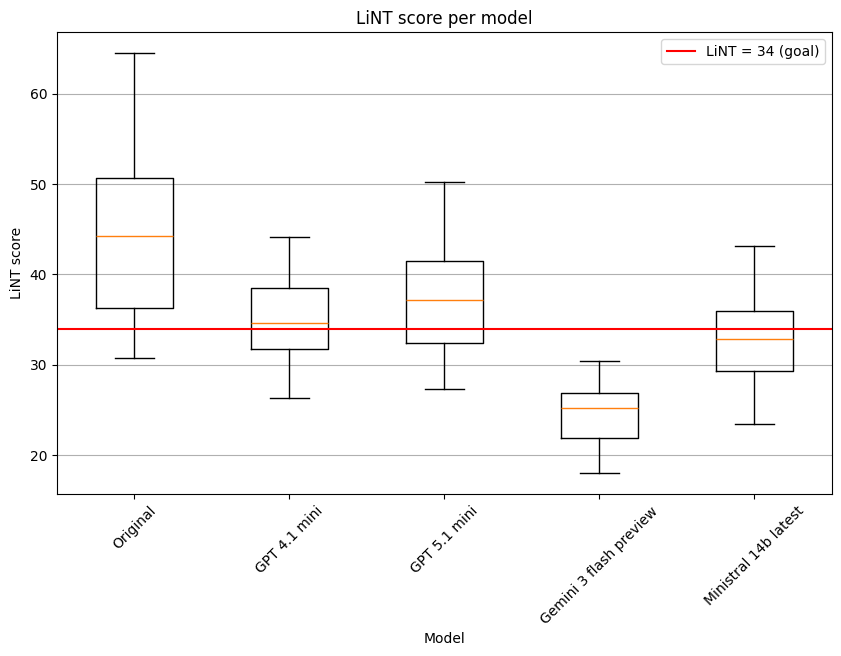

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(valk_model.values())
ax.set_xticklabels(list(valk_model.keys()), rotation = 45)
ax.set_title("LiNT score per model")
ax.set_ylabel("LiNT score")
ax.set_xlabel("Model")
ax.axhline(y=34, color='r', linestyle='-', label="LiNT = 34 (goal)")# ax.
ax.grid(axis='y')
ax.legend()
plt.show()

# Open vs Closed, Small vs Large

In [24]:
anova_check_model_df


,tekst,prompt_type,model,score
0,0,Org,Original,51.787887
1,1,Org,Original,44.271952
2,2,Org,Original,42.014847
3,3,Org,Original,41.730474
4,4,Org,Original,36.416338
...,...,...,...,...
1315,35,dummy_prompt,Mistral/ministral-14b-latest,35.047580
1316,36,dummy_prompt,Mistral/ministral-14b-latest,37.246550
1317,37,dummy_prompt,Mistral/ministral-14b-latest,31.498096
1318,38,dummy_prompt,Mistral/ministral-14b-latest,34.569511


In [25]:
mdls = ['ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest']

In [26]:
anova_check_model_df

,tekst,prompt_type,model,score
0,0,Org,Original,51.787887
1,1,Org,Original,44.271952
2,2,Org,Original,42.014847
3,3,Org,Original,41.730474
4,4,Org,Original,36.416338
...,...,...,...,...
1315,35,dummy_prompt,Mistral/ministral-14b-latest,35.047580
1316,36,dummy_prompt,Mistral/ministral-14b-latest,37.246550
1317,37,dummy_prompt,Mistral/ministral-14b-latest,31.498096
1318,38,dummy_prompt,Mistral/ministral-14b-latest,34.569511


In [27]:
# cosm = anova_check_model_df.loc[anova_check_model_df.model.isin(mdls)]
cosm = anova_check_model_df

cosm

,tekst,prompt_type,model,score
0,0,Org,Original,51.787887
1,1,Org,Original,44.271952
2,2,Org,Original,42.014847
3,3,Org,Original,41.730474
4,4,Org,Original,36.416338
...,...,...,...,...
1315,35,dummy_prompt,Mistral/ministral-14b-latest,35.047580
1316,36,dummy_prompt,Mistral/ministral-14b-latest,37.246550
1317,37,dummy_prompt,Mistral/ministral-14b-latest,31.498096
1318,38,dummy_prompt,Mistral/ministral-14b-latest,34.569511


In [29]:
records_cosm = []

columns = list(cosm.columns.values)
print(columns)
org_texts = {str(object=l): [] for l in range(40)}
closed_texts = {str(object=l): [] for l in range(40)}
open_texts = {str(object=l): None for l in range(40)}

for csm in cosm.itertuples():

    model_type = csm.Index
    print(csm)
    if csm.model in mdls[:3]: # Closed source
        print(csm.model)
        closed_texts[str(csm.tekst)].append(csm.score)
        if len(closed_texts[str(csm.tekst)]) == 3:
            closed_texts[str(csm.tekst)] = np.mean(closed_texts[str(csm.tekst)])
    else: # Closed source
        if csm.model == 'Original': # Original text
            org_texts[str(csm.tekst)] = csm.score
        else:
            open_texts[str(csm.tekst)] = csm.score

['tekst', 'prompt_type', 'model', 'score']
Pandas(Index=0, tekst=0, prompt_type='Org', model='Original', score=51.787887017911295)
Pandas(Index=1, tekst=1, prompt_type='Org', model='Original', score=44.27195203809244)
Pandas(Index=2, tekst=2, prompt_type='Org', model='Original', score=42.01484679202095)
Pandas(Index=3, tekst=3, prompt_type='Org', model='Original', score=41.73047397969161)
Pandas(Index=4, tekst=4, prompt_type='Org', model='Original', score=36.416338260970214)
Pandas(Index=5, tekst=5, prompt_type='Org', model='Original', score=53.45974778002985)
Pandas(Index=6, tekst=6, prompt_type='Org', model='Original', score=33.788448096944194)
Pandas(Index=7, tekst=7, prompt_type='Org', model='Original', score=34.29964098773658)
Pandas(Index=8, tekst=8, prompt_type='Org', model='Original', score=35.638115979818764)
Pandas(Index=9, tekst=9, prompt_type='Org', model='Original', score=35.942525997382106)
Pandas(Index=10, tekst=10, prompt_type='Org', model='Original', score=36.048157092

In [31]:
clsdum = dict({
    "text": list(range(40)) +  list(range(40)) + list(range(40)),
    "model_type": ['org_text'] * 40 + ['closed_dummy'] * 40 + ['open_dummy'] * 40,
    "score":list(org_texts.values()) + list(closed_texts.values()) + list(open_texts.values())
})


In [32]:
anova_check_cosm_df = pd.DataFrame(clsdum)
anova_check_cosm_df

,text,model_type,score
0,0,org_text,51.787887
1,1,org_text,44.271952
2,2,org_text,42.014847
3,3,org_text,41.730474
4,4,org_text,36.416338
...,...,...,...
115,35,open_dummy,35.047580
116,36,open_dummy,37.246550
117,37,open_dummy,31.498096
118,38,open_dummy,34.569511


In [33]:
pg.normality(data=anova_check_cosm_df, dv='score', group='model_type')

,W,pval,normal
model_type,,,
org_text,0.965463,0.256209,True
closed_dummy,0.965466,0.256269,True
open_dummy,0.987722,0.935909,True


In [34]:
print(pg.sphericity(data=anova_check_cosm_df, dv='score', subject='text', within='model_type'))

SpherResults(spher=False, W=0.3145245946231729, chi2=43.954334136794124, dof=2, pval=2.8538925274864797e-10)


In [35]:
# if sphericity = False, report the p_GG_corr p value (Greenhouse Geisser)
print(pg.rm_anova(data=anova_check_cosm_df, dv='score', subject='text', within='model_type', detailed=True, correction=True, effsize='n2'))

       Source           SS  DF           MS           F         p_unc  \
0  model_type  3701.078778   2  1850.539389  140.268349  1.461768e-26   
1       Error  1029.042354  78    13.192851         NaN           NaN   

      p_GG_corr        n2       eps sphericity   W_spher       p_spher  
0  9.519884e-17  0.446079  0.593304      False  0.314525  2.853893e-10  
1           NaN       NaN       NaN        NaN       NaN           NaN  


In [36]:
# If p corrected value <0.05, then you can assume it is statistically significant. 

posthocs = pg.pairwise_tests(
    data=anova_check_cosm_df, dv='score', subject='text', within='model_type', padjust="bonf", effsize='eta_square'
)
posthocs

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,eta_square
0,model_type,closed_dummy,open_dummy,True,True,-0.027754,39.0,two-sided,9.780002e-01,1.000000e+00,bonf,0.171,0.000001
1,model_type,closed_dummy,org_text,True,True,-12.839470,39.0,two-sided,1.384778e-15,4.154333e-15,bonf,4.62e+12,0.421236
2,model_type,open_dummy,org_text,True,True,-11.695632,39.0,two-sided,2.532806e-14,7.598419e-14,bonf,2.818e+11,0.408599


## Table for paper

In [186]:
for mdl in list(anova_check_cosm_df.model_type.unique())[1:]:
    print(mdl)
    res = anova_check_cosm_df[anova_check_cosm_df.model_type == 'org_text'].score.values - anova_check_cosm_df[anova_check_cosm_df.model_type == mdl].score.values
    if np.min(res) > 0:
        print("good vibes only", np.min(res))
    else:
        print("fck", np.min(res), np.where(res < 0.0))
        print(res)

closed_dummy
good vibes only 0.37160075386762514
open_dummy
good vibes only 3.8932962689988706


In [188]:
agg_table = anova_check_cosm_df.groupby('model_type')['score'].aggregate([np.min, np.median, np.max, np.mean, np.std])
# agg_table
print(agg_table.to_latex(escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & min & median & max & mean & std \\
model\_type &  &  &  &  &  \\
\midrule
closed\_dummy & 24.63 & 32.28 & 40.82 & 32.60 & 4.13 \\
open\_dummy & 23.46 & 32.79 & 43.09 & 32.61 & 4.68 \\
org\_text & 30.74 & 44.25 & 64.49 & 44.38 & 8.72 \\
\bottomrule
\end{tabular}



## Plot results means

In [37]:
grouped_model_type = anova_check_cosm_df.groupby('model_type')
grouped_model_type.groups.items()

dict_items([('closed_dummy', RangeIndex(start=40, stop=80, step=1)), ('open_dummy', RangeIndex(start=80, stop=120, step=1)), ('org_text', RangeIndex(start=0, stop=40, step=1))])

In [38]:
valk_model_type = dict(
    {
        'Original': dict(tuple(grouped_model_type))['org_text']['score'].values,
        'Open model': dict(tuple(grouped_model_type))['open_dummy']['score'].values,
        'Closed models': dict(tuple(grouped_model_type))['closed_dummy']['score'].values,
    }

)
valk_model_type

{'Original': array([51.78788702, 44.27195204, 42.01484679, 41.73047398, 36.41633826,
        53.45974778, 33.7884481 , 34.29964099, 35.63811598, 35.942526  ,
        36.04815709, 49.57545814, 53.04274792, 53.68063737, 43.20998372,
        30.74022212, 53.16578509, 64.48584901, 31.28092504, 40.35790065,
        42.27971024, 45.10012882, 38.47826859, 44.228571  , 45.40480214,
        40.7485339 , 32.08573087, 44.95534597, 32.82549627, 33.79125201,
        56.32801162, 58.84585487, 45.96075655, 63.74358302, 39.10405441,
        46.74079593, 50.22265812, 47.5599297 , 52.42048877, 49.62476538]),
 'Open model': array([36.12651384, 28.57798307, 31.85152401, 35.13686578, 24.52640962,
        37.07980518, 29.33844521, 30.38733181, 29.09867003, 29.64532185,
        29.91357867, 38.25302095, 43.08856709, 41.28204764, 23.74898654,
        23.46019711, 25.91378208, 35.86238525, 25.80351084, 29.34184794,
        32.8537264 , 32.83386177, 32.74200457, 36.28357194, 32.23989241,
        33.47665351, 27

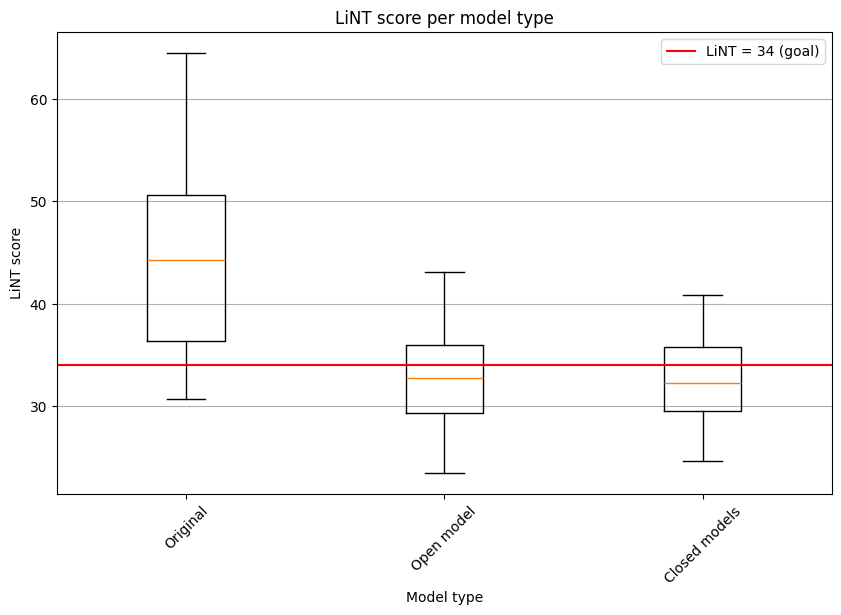

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(valk_model_type.values())
ax.set_xticklabels(list(valk_model_type.keys()), rotation = 45)
ax.set_title("LiNT score per model type")
ax.set_ylabel("LiNT score")
ax.set_xlabel("Model type")
ax.axhline(y=34, color='r', linestyle='-', label="LiNT = 34 (goal)")# ax.
ax.grid(axis='y')
ax.legend()
plt.show()

# Effect of LiNT features

In [6]:
featlvl = zkb.xs(LINT_FEATURE, 1, 1)
featlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103...","[-10.837340387071144, -11.717945105265855, -8....","[-4.517450223326719, -9.29620573354876, -9.869...","[-20.491910211027438, -21.09355145383897, -17....","[-12.452174166631742, -14.970689561995542, -9...."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783...","[-8.950911496217195, -7.341007145740463, -12.1...","[-4.310817698572123, -3.3619820267217833, -7.9...","[-20.552720624897667, -27.163550013634648, -17...","[-15.461479726164356, -13.430145443381463, -9...."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54...","[-9.361010019434168, -12.967162810460948, -14....","[-7.744431632020671, -9.624880481733356, -10.3...","[-27.63058386534123, -27.324002940022808, -19....","[-22.878532050109477, -20.110663394981103, -8...."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974...","[-7.8251378963908635, -10.737842415425604, -6....","[-4.364230884768382, -8.50374344426659, -5.052...","[-26.398741678209397, -21.575662419094044, -14...","[-11.8533067651124, -14.264377455172777, -13.0..."
meta_no_metric,"[51.787887017911295, 44.27195203809244, 42.014...","[42.28958633443007, 30.596528711552153, 31.171...","[41.7425487408478, 32.313725566640244, 32.3828...","[24.21361144906966, 15.451983306893368, 27.302...","[33.12911222903992, 24.939663988548645, 30.576...","[-9.498300683481226, -13.675423326540283, -10....","[-10.045338277063493, -11.958226471452193, -9....","[-27.574275568841635, -28.81996873119907, -14....","[-18.658774788871376, -19.33228804954379, -11...."
meta_no_lint,"[51.787887017911295, 44.27195203809244, 42.014...","[35.63656733739761, 29.216412158987538, 27.823...","[44.88418525326825, 27.939051535063115, 32.234...","[31.402888468691657, 18.163058828739622, 26.18...","[30.585526700917242, 21.062738000493937, 29.63...","[-16.151319680513687, -15.055539879104899, -14...","[-6.903701764643046, -16.33290050302932, -9.77...","[-20.384998549219638, -26.108893209352814, -15...","[-21.202360316994053, -23.2092140375985, -12.3..."


In [7]:
chcks = ['meta', 'meta_no_metric', 'meta_no_lint']
chcks_idx = [2, 4, 5] # Integer index of chcks prompts.

In [8]:
max_val_feat = 0
for idx, row in featlvl.iloc[chcks_idx,0:5].iterrows(): # Exclude meta_no_lint and meta_no_metric rows.
    vls = np.array([r for r in row.values]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    temp_max = np.max(vls)
    if temp_max > max_val_feat:
        max_val_feat = temp_max
print("MAX", max_val_feat)

MAX 68.48813079213978


In [9]:
dummy_models = []
all_gains = []
all_gains_v2 = []
postpre = []
for idx, row in featlvl.iloc[:,0:5].iterrows():
    print("=====", idx)
    org_vls = row.values[0]
    vls = np.array([r for r in row.values[1:]]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    avg_model_score_per_text = np.mean(vls, axis = 0)
    post_min_pre = avg_model_score_per_text - org_vls
    max_min_pre = max_val_feat - org_vls
    gain = post_min_pre / max_min_pre
    gain_v2 = post_min_pre / org_vls
    # NORMALIZED GAIN: https://www.physport.org/recommendations/Entry.cfm?ID=93334
    dummy_models.append(avg_model_score_per_text)
    all_gains.append(gain)
    all_gains_v2.append(gain_v2)
    postpre.append(post_min_pre)

===== standard
===== roleplay
===== meta
===== cot
===== meta_no_metric
===== meta_no_lint


In [10]:
featlvl['dummy_model'] = dummy_models
featlvl['post-min-pre'] = postpre
featlvl['norm.gain'] = all_gains
featlvl['norm.gain.v2'] = all_gains_v2

In [11]:
featlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff,dummy_model,post-min-pre,norm.gain,norm.gain.v2
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103...","[-10.837340387071144, -11.717945105265855, -8....","[-4.517450223326719, -9.29620573354876, -9.869...","[-20.491910211027438, -21.09355145383897, -17....","[-12.452174166631742, -14.970689561995542, -9....","[39.71316827089703, 30.002354074430155, 30.730...","[-12.074718747014266, -14.269597963662282, -11...","[-0.7230264965142456, -0.5892588632001796, -0....","[-0.23315720030898573, -0.3223168915475976, -0..."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783...","[-8.950911496217195, -7.341007145740463, -12.1...","[-4.310817698572123, -3.3619820267217833, -7.9...","[-20.552720624897667, -27.163550013634648, -17...","[-15.461479726164356, -13.430145443381463, -9....","[39.46890463144846, 31.447780880722846, 30.337...","[-12.318982386462835, -12.824171157369591, -11...","[-0.7376528482460396, -0.5295703871208927, -0....","[-0.23787381752420614, -0.289668075768049, -0...."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54...","[-9.361010019434168, -12.967162810460948, -14....","[-7.744431632020671, -9.624880481733356, -10.3...","[-27.63058386534123, -27.324002940022808, -19....","[-22.878532050109477, -20.110663394981103, -8....","[34.88424762618491, 26.765274631292883, 28.800...","[-16.903639391726387, -17.506677406799554, -13...","[-1.0121792005103407, -0.7229331094970379, -0....","[-0.32640141092993646, -0.39543495601315415, -..."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974...","[-7.8251378963908635, -10.737842415425604, -6....","[-4.364230884768382, -8.50374344426659, -5.052...","[-26.398741678209397, -21.575662419094044, -14...","[-11.8533067651124, -14.264377455172777, -13.0...","[39.17753271179103, 30.501545604602683, 32.423...","[-12.610354306120264, -13.770406433489754, -9....","[-0.7551000139040085, -0.5686448953548565, -0....","[-0.2435000737094924, -0.31104132073601437, -0..."
meta_no_metric,"[51.787887017911295, 44.27195203809244, 42.014...","[42.28958633443007, 30.596528711552153, 31.171...","[41.7425487408478, 32.313725566640244, 32.3828...","[24.21361144906966, 15.451983306893368, 27.302...","[33.12911222903992, 24.939663988548645, 30.576...","[-9.498300683481226, -13.675423326540283, -10....","[-10.045338277063493, -11.958226471452193, -9....","[-27.574275568841635, -28.81996873119907, -14....","[-18.658774788871376, -19.33228804954379, -11....","[35.343714688346864, 25.825475393408603, 30.35...","[-16.44417232956443, -18.446476644683834, -11....","[-0.9846666043845884, -0.7617418434194866, -0....","[-0.3175293157621409, -0.4166628259086505, -0...."
meta_no_lint,"[51.787887017911295, 44.27195203809244, 42.014...","[35.63656733739761, 29.216412158987538, 27.823...","[44.88418525326825, 27.939051535063115, 32.234...","[31.402888468691657, 18.163058828739622, 26.18...","[30.585526700917242, 21.062738000493937, 29.63...

In [12]:
# Create for dummy model.

records_feat = []

columns = list(featlvl.columns.values)
print(columns)
for models in featlvl.iloc[chcks_idx,:].itertuples():
    # print(prompt)
    print(len(models))
    print(models.Index)
    # print(models._2)
    # print(models)
    # print(models.column)
    # print(type(models), len(models))
    prompt_type = models.Index
    for index, lint_score in enumerate(models[1:]):
        # print(model)
        print("lengte", len(lint_score))
        print(index, lint_score)
        
        for text, ls in enumerate(lint_score):
            print("tekst", text, "lint score", ls)
            records_feat.append(
                {
                    "tekst": text,
                    "prompt_type": prompt_type,
                    "model": columns[index],
                    "score": ls
                }
            )
    

['Org', 'ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest', 'ChatGPT 4.1 mini/gpt-4.1-mini - diff', 'GPT 5.1 mini/gpt-5-mini - diff', 'Gemini/gemini-3-flash-preview - diff', 'Mistral/ministral-14b-latest - diff', 'dummy_model', 'post-min-pre', 'norm.gain', 'norm.gain.v2']
14
meta
lengte 40
0 [51.78788702 44.27195204 42.01484679 41.73047398 36.41633826 53.45974778
 33.7884481  34.29964099 35.63811598 35.942526   36.04815709 49.57545814
 53.04274792 53.68063737 43.20998372 30.74022212 53.16578509 64.48584901
 31.28092504 40.35790065 42.27971024 45.10012882 38.47826859 44.228571
 45.40480214 40.7485339  32.08573087 44.95534597 32.82549627 33.79125201
 56.32801162 58.84585487 45.96075655 63.74358302 39.10405441 46.74079593
 50.22265812 47.5599297  52.42048877 49.62476538]
tekst 0 lint score 51.787887017911295
tekst 1 lint score 44.27195203809244
tekst 2 lint score 42.01484679202095
tekst 3 lint score 41.73047397969161

In [13]:
long_df = pd.DataFrame(records_feat)
long_df

,tekst,prompt_type,model,score
0,0,meta,Org,51.787887
1,1,meta,Org,44.271952
2,2,meta,Org,42.014847
3,3,meta,Org,41.730474
4,4,meta,Org,36.416338
...,...,...,...,...
1555,35,meta_no_lint,norm.gain.v2,-0.290159
1556,36,meta_no_lint,norm.gain.v2,-0.328677
1557,37,meta_no_lint,norm.gain.v2,-0.349996
1558,38,meta_no_lint,norm.gain.v2,-0.442517


In [14]:
all_models_df = long_df[long_df.model.isin(['ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest'])] 
all_models_df

,tekst,prompt_type,model,score
40,0,meta,ChatGPT 4.1 mini/gpt-4.1-mini,42.426877
41,1,meta,ChatGPT 4.1 mini/gpt-4.1-mini,31.304789
42,2,meta,ChatGPT 4.1 mini/gpt-4.1-mini,27.986886
43,3,meta,ChatGPT 4.1 mini/gpt-4.1-mini,36.480907
44,4,meta,ChatGPT 4.1 mini/gpt-4.1-mini,33.084710
...,...,...,...,...
1235,35,meta_no_lint,Mistral/ministral-14b-latest,32.977466
1236,36,meta_no_lint,Mistral/ministral-14b-latest,35.488360
1237,37,meta_no_lint,Mistral/ministral-14b-latest,28.898954
1238,38,meta_no_lint,Mistral/ministral-14b-latest,28.488998


In [71]:
# long_df.loc[(long_df.prompt_type == 'standard') & (long_df.model == 'Org'), 'prompt_type'] = 'Original'
# long_df

,tekst,prompt_type,model,score
0,0,meta,Org,51.787887
1,1,meta,Org,44.271952
2,2,meta,Org,42.014847
3,3,meta,Org,41.730474
4,4,meta,Org,36.416338
...,...,...,...,...
1555,35,meta_no_lint,norm.gain.v2,-0.290159
1556,36,meta_no_lint,norm.gain.v2,-0.328677
1557,37,meta_no_lint,norm.gain.v2,-0.349996
1558,38,meta_no_lint,norm.gain.v2,-0.442517


In [ ]:
# This has the orignal lint scores for tekst without prompt (baseline) and contains 4 prompts * 40 dummy (mean) values.
# anova_check_df = long_df[(long_df.model.isin(['dummy_model'])) | ((long_df.prompt_type == 'Original') & (long_df.model == 'Org'))]

# anova_check_df

In [75]:
anova_check_feat_df = long_df[(long_df.model.isin(['dummy_model']))]
anova_check_feat_df

,tekst,prompt_type,model,score
360,0,meta,dummy_model,34.884248
361,1,meta,dummy_model,26.765275
362,2,meta,dummy_model,28.800418
363,3,meta,dummy_model,31.886091
364,4,meta,dummy_model,26.545402
...,...,...,...,...
1435,35,meta_no_lint,dummy_model,33.178532
1436,36,meta_no_lint,dummy_model,33.715604
1437,37,meta_no_lint,dummy_model,30.914168
1438,38,meta_no_lint,dummy_model,29.223537


In [76]:
pg.normality(data=anova_check_feat_df, dv='score', group='prompt_type')

,W,pval,normal
prompt_type,,,
meta,0.977048,0.581151,True
meta_no_metric,0.981436,0.742612,True
meta_no_lint,0.983687,0.822106,True


In [77]:
pg.sphericity(data=anova_check_feat_df, dv='score', subject='tekst', within='prompt_type')

SpherResults(spher=True, W=0.9467287110803968, chi2=2.080222553221244, dof=2, pval=0.3534153529080056)

In [78]:
# if sphericity = False, report the p_GG_corr p value (Greenhouse Geisser)
print(pg.rm_anova(data=anova_check_feat_df, dv='score', subject='tekst', within='prompt_type', detailed=True, correction=True, effsize='n2'))

        Source          SS  DF         MS         F     p_unc  p_GG_corr  \
0  prompt_type   58.355050   2  29.177525  7.216681  0.001332   0.001639   
1        Error  315.359234  78   4.043067       NaN       NaN        NaN   

         n2       eps sphericity   W_spher   p_spher  
0  0.027347  0.949423       True  0.946729  0.353415  
1       NaN       NaN        NaN       NaN       NaN  


In [79]:
# If p corrected value <0.05, then you can assume it is statistically significant. 
posthocs = pg.pairwise_tests(
    data=anova_check_feat_df, dv='score', subject='tekst', within='prompt_type', padjust="bonf", effsize='eta_square'
)
posthocs

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,eta_square
0,prompt_type,meta,meta_no_lint,True,True,2.505264,39.0,two-sided,0.016522,0.049565,bonf,2.663,0.022953
1,prompt_type,meta,meta_no_metric,True,True,3.549076,39.0,two-sided,0.001026,0.003079,bonf,29.836,0.038642
2,prompt_type,meta_no_lint,meta_no_metric,True,True,1.102588,39.0,two-sided,0.276964,0.830892,bonf,0.3,0.002297


## Table for paper

In [189]:
anova_check_feat_df

,tekst,prompt_type,model,score
360,0,meta,dummy_model,34.884248
361,1,meta,dummy_model,26.765275
362,2,meta,dummy_model,28.800418
363,3,meta,dummy_model,31.886091
364,4,meta,dummy_model,26.545402
...,...,...,...,...
1435,35,meta_no_lint,dummy_model,33.178532
1436,36,meta_no_lint,dummy_model,33.715604
1437,37,meta_no_lint,dummy_model,30.914168
1438,38,meta_no_lint,dummy_model,29.223537


In [194]:
for mdl in list(anova_check_feat_df.prompt_type.unique())[1:]:
    print(mdl)
    res = anova_check_feat_df[anova_check_feat_df.prompt_type == 'meta'].score.values - anova_check_feat_df[anova_check_feat_df.prompt_type == mdl].score.values
    if np.min(res) > 0:
        print("good vibes only", np.min(res))
    else:
        print("fck", np.min(res), np.where(res < 0.0), len(np.where(res < 0.0)[0]), np.mean(res))
        print(res)


meta_no_metric
fck -2.8896167704196714 (array([ 0,  2,  5, 13, 16, 17, 20, 24, 25, 30, 31, 33, 35, 36]),) 14 1.6484227347531593
[-4.59467062e-01  9.39799238e-01 -1.55775957e+00  1.90919170e+00
  3.32725180e+00 -6.49074913e-01  2.33594135e+00  6.84121661e+00
  8.24479218e-01  3.62162466e+00  1.24226446e+00  7.83244950e-01
  1.23331069e+00 -1.62992863e+00  4.01870490e+00  4.66416677e+00
 -1.67121038e+00 -2.23714851e+00  7.61543244e+00  3.48441851e+00
 -1.84613089e+00  2.35251330e+00  4.16034867e+00  1.04975285e+00
 -8.61035203e-03 -3.37182376e-02  2.26733605e+00  3.62248271e+00
  1.03843772e+01  2.14543687e+00 -1.95188574e+00 -2.88961677e+00
  6.58045672e+00 -1.73498952e+00  1.71482241e+00 -2.92115054e-01
 -5.00218246e-01  6.75468153e-01  3.89221630e+00  1.71252469e+00]
meta_no_lint
fck -6.065927327780017 (array([ 0,  2,  6, 11, 12, 13, 17, 25, 29, 31, 33, 35, 37]),) 13 1.2119499879680926
[-0.74304431  2.6699595  -0.17018218  0.92966908  2.8011687   4.3593222
 -1.29197909  0.23183197  3.

In [191]:
agg_table = anova_check_feat_df.groupby('prompt_type')['score'].aggregate([np.min, np.median, np.max, np.mean, np.std])
# agg_table
print(agg_table.to_latex(escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & min & median & max & mean & std \\
prompt\_type &  &  &  &  &  \\
\midrule
meta & 23.61 & 31.61 & 38.23 & 31.15 & 3.40 \\
meta\_no\_lint & 21.27 & 29.53 & 39.33 & 29.94 & 4.35 \\
meta\_no\_metric & 18.95 & 28.24 & 38.35 & 29.50 & 4.63 \\
\bottomrule
\end{tabular}



## Plots

In [80]:
prompt_feat_grouped = anova_check_feat_df.groupby('prompt_type')
prompt_feat_grouped.groups.items()

dict_items([('meta', Index([360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373,
       374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387,
       388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399],
      dtype='int64')), ('meta_no_lint', Index([1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409, 1410, 1411,
       1412, 1413, 1414, 1415, 1416, 1417, 1418, 1419, 1420, 1421, 1422, 1423,
       1424, 1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433, 1434, 1435,
       1436, 1437, 1438, 1439],
      dtype='int64')), ('meta_no_metric', Index([880, 881, 882, 883, 884, 885, 886, 887, 888, 889, 890, 891, 892, 893,
       894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904, 905, 906, 907,
       908, 909, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919],
      dtype='int64'))])

In [85]:
valk_prompt_feat = dict(
    {
        'Meta (Formula & Metric)': dict(tuple(prompt_feat_grouped))['meta']['score'].values,
        'Meta (No Lint Formula)': dict(tuple(prompt_feat_grouped))['meta_no_lint']['score'].values,
        'Meta (No Metric values)': dict(tuple(prompt_feat_grouped))['meta_no_metric']['score'].values,
    }

)

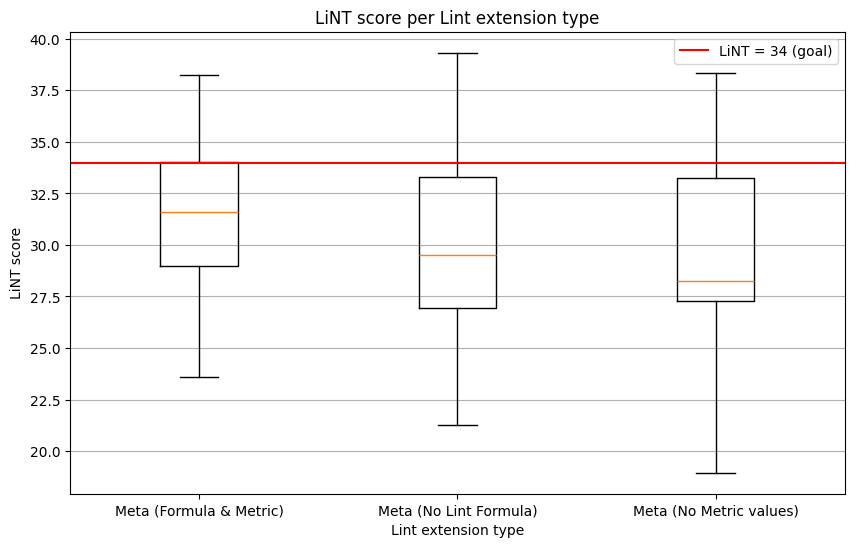

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(valk_prompt_feat.values())
ax.set_xticklabels(list(valk_prompt_feat.keys()))
ax.set_title("LiNT score per Lint extension type")
ax.set_ylabel("LiNT score")
ax.set_xlabel("Lint extension type")
ax.axhline(y=34, color='r', linestyle='-', label="LiNT = 34 (goal)")# ax.
ax.grid(axis='y')
ax.legend()
plt.show()

In [201]:
all_models_df

,tekst,prompt_type,model,score
40,0,meta,ChatGPT 4.1 mini/gpt-4.1-mini,42.426877
41,1,meta,ChatGPT 4.1 mini/gpt-4.1-mini,31.304789
42,2,meta,ChatGPT 4.1 mini/gpt-4.1-mini,27.986886
43,3,meta,ChatGPT 4.1 mini/gpt-4.1-mini,36.480907
44,4,meta,ChatGPT 4.1 mini/gpt-4.1-mini,33.084710
...,...,...,...,...
1235,35,meta_no_lint,Mistral/ministral-14b-latest,32.977466
1236,36,meta_no_lint,Mistral/ministral-14b-latest,35.488360
1237,37,meta_no_lint,Mistral/ministral-14b-latest,28.898954
1238,38,meta_no_lint,Mistral/ministral-14b-latest,28.488998


In [15]:
interact = list(itertools.product(list(all_models_df.model.unique()), list(all_models_df.prompt_type.unique())))
print(interact)

[('ChatGPT 4.1 mini/gpt-4.1-mini', 'meta'), ('ChatGPT 4.1 mini/gpt-4.1-mini', 'meta_no_metric'), ('ChatGPT 4.1 mini/gpt-4.1-mini', 'meta_no_lint'), ('GPT 5.1 mini/gpt-5-mini', 'meta'), ('GPT 5.1 mini/gpt-5-mini', 'meta_no_metric'), ('GPT 5.1 mini/gpt-5-mini', 'meta_no_lint'), ('Gemini/gemini-3-flash-preview', 'meta'), ('Gemini/gemini-3-flash-preview', 'meta_no_metric'), ('Gemini/gemini-3-flash-preview', 'meta_no_lint'), ('Mistral/ministral-14b-latest', 'meta'), ('Mistral/ministral-14b-latest', 'meta_no_metric'), ('Mistral/ministral-14b-latest', 'meta_no_lint')]


In [16]:
interaction_dict = dict()
for inter1, inter2 in interact:
    interaction_dict[f"{inter1} * {inter2}"] = []
interaction_dict


{'ChatGPT 4.1 mini/gpt-4.1-mini * meta': [],
 'ChatGPT 4.1 mini/gpt-4.1-mini * meta_no_metric': [],
 'ChatGPT 4.1 mini/gpt-4.1-mini * meta_no_lint': [],
 'GPT 5.1 mini/gpt-5-mini * meta': [],
 'GPT 5.1 mini/gpt-5-mini * meta_no_metric': [],
 'GPT 5.1 mini/gpt-5-mini * meta_no_lint': [],
 'Gemini/gemini-3-flash-preview * meta': [],
 'Gemini/gemini-3-flash-preview * meta_no_metric': [],
 'Gemini/gemini-3-flash-preview * meta_no_lint': [],
 'Mistral/ministral-14b-latest * meta': [],
 'Mistral/ministral-14b-latest * meta_no_metric': [],
 'Mistral/ministral-14b-latest * meta_no_lint': []}

In [17]:
for idx, rw in all_models_df.iterrows():
    print(rw.model, rw.prompt_type)
    interaction_dict[f"{rw.model} * {rw.prompt_type}"].append(rw.score)


ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt-4.1-mini meta
ChatGPT 4.1 mini/gpt

In [18]:
mean_p_inter = pd.DataFrame(interaction_dict)
mean_p_inter

,ChatGPT 4.1 mini/gpt-4.1-mini * meta,ChatGPT 4.1 mini/gpt-4.1-mini * meta_no_metric,ChatGPT 4.1 mini/gpt-4.1-mini * meta_no_lint,GPT 5.1 mini/gpt-5-mini * meta,GPT 5.1 mini/gpt-5-mini * meta_no_metric,GPT 5.1 mini/gpt-5-mini * meta_no_lint,Gemini/gemini-3-flash-preview * meta,Gemini/gemini-3-flash-preview * meta_no_metric,Gemini/gemini-3-flash-preview * meta_no_lint,Mistral/ministral-14b-latest * meta,Mistral/ministral-14b-latest * meta_no_metric,Mistral/ministral-14b-latest * meta_no_lint
0,42.426877,42.289586,35.636567,44.043455,41.742549,44.884185,24.157303,24.213611,31.402888,28.909355,33.129112,30.585527
1,31.304789,30.596529,29.216412,34.647072,32.313726,27.939052,16.947949,15.451983,18.163059,24.161289,24.939664,21.062738
2,27.986886,31.171016,27.823807,31.642991,32.382826,32.234854,22.026977,27.302621,26.185849,33.544820,30.576250,29.637892
3,36.480907,32.756976,33.675878,34.201725,34.138439,35.173500,20.998072,20.343432,20.761349,35.863662,32.668752,34.214962
4,33.084710,28.907601,26.652112,31.340135,27.568238,29.631173,18.233698,13.541761,16.155662,23.523064,22.855000,22.537985
5,41.858846,39.172251,29.119269,38.949371,34.355801,40.517318,29.471336,36.846159,24.145130,31.567234,34.068876,30.627782
6,32.552209,28.876703,27.731000,28.493426,30.319398,28.636024,21.266204,12.175268,25.777011,25.943457,27.540160,31.279177
7,31.966233,18.174703,26.747239,29.413589,27.866869,26.721725,22.913713,13.874478,32.279345,32.642635,29.655253,30.260533
8,31.812236,29.201515,25.235111,29.571385,29.521925,29.356341,27.552918,24.786549,22.721270,27.254348,29.382982,23.830100
9,34.432839,29.112536,27.072868,32.713711,31.138392,26.127223,29.624400,25.022838,24.473727,29.931431,26.942118,25.562983


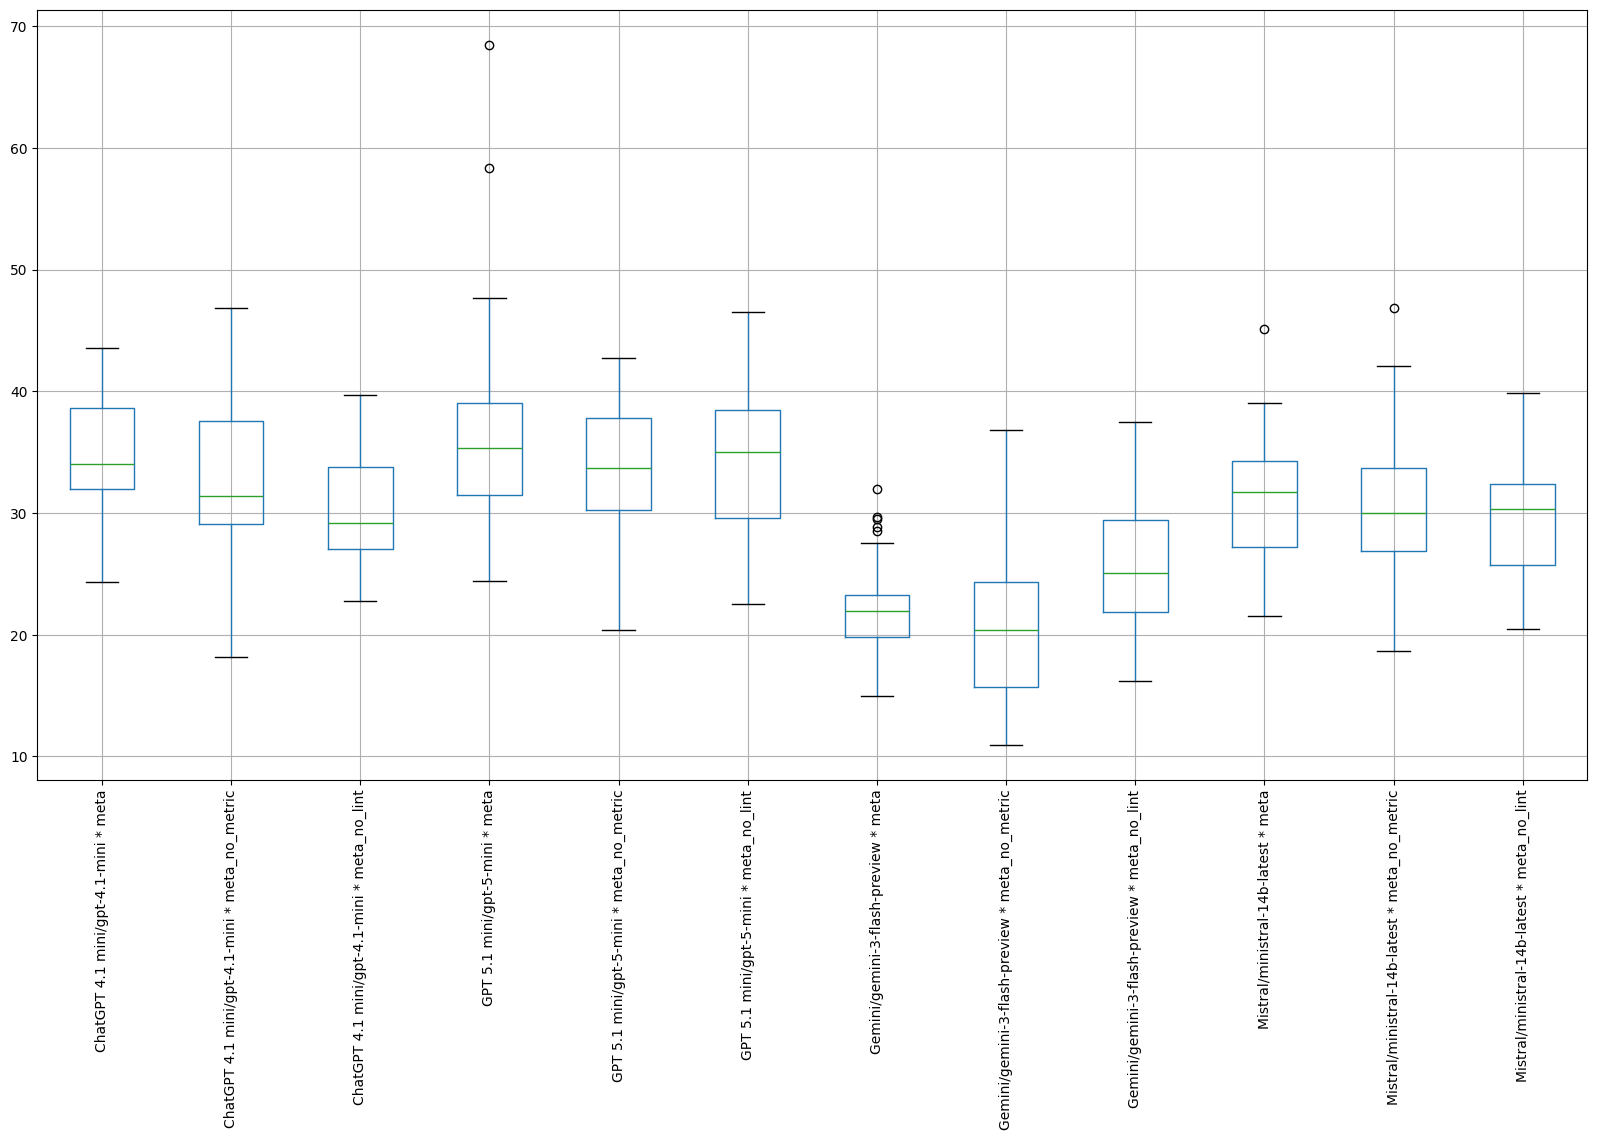

In [25]:
mean_p_inter.boxplot(rot=90, figsize=(20,10))
plt.show()